<a href="https://colab.research.google.com/github/faiym/FatimaMajid-portfolio/blob/main/skyeyes_Drone_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install ultralytics opencv-python numpy scikit-learn

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the pre-trained model
model = YOLO('yolov8n.pt')

# Run inference on a sample image (download one first)
!wget -O sample_drone.jpg "https://github.com/ultralytics/yolov5/raw/master/data/images/zidane.jpg"
results = model('sample_drone.jpg')

# Show the results
for r in results:
    im_array = r.plot()  # plot a BGR numpy array of predictions
    cv2_imshow(im_array) # display the image in Colab

--2025-08-26 15:24:08--  https://github.com/ultralytics/yolov5/raw/master/data/images/zidane.jpg
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg [following]
--2025-08-26 15:24:08--  https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/zidane.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... ^C



In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO('yolov8n.pt')

# Open the video file
video_path = "simulated_feed.mp4"
cap = cv2.VideoCapture(video_path)

# Loop through the video frames
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Display the annotated frame (in Colab)
    cv2_imshow(annotated_frame)
    # To break the loop, Colab will eventually stop it. For a local script, you'd use cv2.waitKey(1)

cap.release()

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the pre-trained YOLOv8 model (the 'n' in 'yolov8n' stands for 'nano' - it's fast)
model = YOLO('yolov8n.pt')

# 1. REPLACE THIS WITH YOUR UPLOADED VIDEO'S FILENAME
# If your file is called "my_drone_video.mp4", change the name below.
video_filename = 'simulated_feed.mp4'

# 2. Open the uploaded video file
cap = cv2.VideoCapture(video_filename)

# 3. Loop through every frame of the video
while cap.isOpened():
    # Read the next frame
    success, frame = cap.read()

    # If the frame was not read successfully (end of video), break the loop
    if not success:
        print("Finished processing video.")
        break

    # 4. RUN THE AI MODEL ON THE FRAME
    # This is where the magic happens. The model analyzes the frame for objects.
    results = model(frame)

    # 5. DRAW THE RESULTS ON THE FRAME
    # This takes the results and draws bounding boxes and labels around any detected drones.
    annotated_frame = results[0].plot()  # 'plot()' creates the visualized frame

    # 6. DISPLAY THE FRAME WITH DETECTIONS IN COLAB
    # This shows the video frame with bounding boxes directly in your notebook.
    cv2_imshow(annotated_frame)
    break  # !!! IMPORTANT: Remove this 'break' to process the entire video.
           # For now, it stops after one frame so you can test quickly.

# 7. Release the video capture object and close windows
cap.release()
cv2.destroyAllWindows()

In [ ]:
import os
from google.colab import files
from google.colab import drive

# Method 1: Check if the file was uploaded via files.upload()
# This lists all files in your current Colab workspace (the left sidebar)
print("--- Files in current Colab session directory: ---")
!ls -la

# Method 2: If you mounted Google Drive, check the path
# Uncomment the next two lines if you used drive.mount()
# drive.mount('/content/drive')
# print("\n--- Example files in Google Drive: ---")
# !ls -la "/content/drive/MyDrive/" | head -10 # Shows first 10 items

print("\nPlease check the output above for your video file's exact name.")

In [ ]:
# This command renames the complicated file to a simple one.
!mv "simulated_511_feed.mp4. - Made with Clipchamp.mp4" demo_video.mp4

# List files again to confirm the rename worked
print("File renamed. New file list:")
!ls -la

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the pre-trained model
model = YOLO('yolov8n.pt')

# Set the simple, correct path
video_path = 'demo_video.mp4'

# Open the video file
cap = cv2.VideoCapture(video_path)

# Read the first frame
success, frame = cap.read()

if success:
    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Display the annotated frame in Colab
    print("✅ Success! Displaying the first frame of your video with AI detections:")
    cv2_imshow(annotated_frame)
else:
    print("❌ Error: Could not read the first frame from the video.")

# Always release the video capture object
cap.release()

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO('yolov8n.pt')
video_path = 'demo_video.mp4'

cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release() # We only need one frame for now

if success:
    # Run inference
    results = model(frame)

    # Get the detection data for the first (and only) result
    result = results[0]

    # Check if any objects were detected at all
    if result.boxes is not None:
        # Get boxes, confidence scores, and class IDs
        boxes = result.boxes.xyxy.cpu().numpy()    # Bounding boxes
        confidences = result.boxes.conf.cpu().numpy() # Confidence scores
        class_ids = result.boxes.cls.cpu().numpy().astype(int) # Class IDs

        # Get the names of the detected classes
        class_names = result.names

        # Loop through each detection
        for i, (box, conf, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            label = class_names[class_id]

            # ONLY PROCESS DETECTIONS CLASSIFIED AS 'DRONE'
            if label == 'drone': # Note: YOLOv8n might not have a great 'drone' class. We'll fix this.
                print(f"Detected a {label} with confidence {conf:.2f}")

                # Draw the box and label (in green for drone)
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green box
                cv2.putText(frame, f'Drone {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

            # else: (you can optionally draw other objects in a different color)
            #    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2) # Blue box for other objects

    # Display the frame with ONLY drone boxes (or no boxes if none found)
    cv2_imshow(frame)
else:
    print("Error reading frame.")

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load a LARGER, more accurate model pre-trained on drone data
# This model is much better at detecting drones specifically.
model = YOLO('yolov8m.pt')  # 'm' for medium, better than 'n' (nano)

video_path = 'demo_video.mp4'
cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

if success:
    results = model(frame)
    result = results[0]

    # Define the class names we care about. Let's also look for 'bird' and 'kite'
    # as drones are often misclassified as these.
    target_classes = ['drone', 'bird', 'kite']

    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        class_names = result.names

        drone_detected = False

        for i, (box, conf, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            label = class_names[class_id]

            # Check if the detection is one of our target classes with high confidence
            if label in target_classes and conf > 0.5: # Confidence threshold of 50%
                drone_detected = True
                print(f"Potential Drone/UAV detected: {label} ({conf:.2f})")

                # Draw the box and label (in green for drone)
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f'UAV: {label} {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        if not drone_detected:
            print("No drones or UAV-like objects detected in this frame.")

    cv2_imshow(frame)

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load a model trained specifically to detect DRONES
# We'll use one from Roboflow's model library
model = YOLO('yolov8s-drones.pt')  # 's' for small, a good balance of speed/accuracy

video_path = 'demo_video.mp4'
cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

if success:
    results = model(frame)
    result = results[0]

    # The classes for this model are different. Let's see what it detected.
    print("Model's class names:", result.names) # This will show us what it can detect

    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        class_names = result.names

        drone_detected = False

        for i, (box, conf, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            label = class_names[class_id]
            print(f"Detected: {label} ({conf:.2f})") # Print everything it finds

            # Now we look for the specific class this model uses for drones
            if label == 'drone' and conf > 0.5: # Adjust the class name based on what we see
                drone_detected = True
                print(f"✅ DRONE DETECTED with confidence {conf:.2f}")

                # Draw the box and label
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f'DRONE {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

                # --- ADD YOUR THREAT LOGIC HERE ---
                drone_center_x = (x1 + x2) / 2
                frame_width = frame.shape[1]
                restricted_zone_start = frame_width * 0.7

                if drone_center_x > restricted_zone_start:
                    threat_status = "THREAT: Approaching restricted zone!"
                    threat_color = (0, 0, 255)
                    cv2.putText(frame, threat_status, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, threat_color, 3)
                    cv2.line(frame, (int(restricted_zone_start), 0), (int(restricted_zone_start), frame.shape[0]), threat_color, 2)

        if not drone_detected:
            print("No drones detected with high confidence.")

    cv2_imshow(frame)
else:
    print("Error reading frame.")

In [ ]:
# Download a YOLOv8 model specifically trained to detect drones
!wget -O drone_model.pt "https://github.com/MuhammadMoinFaisal/AerialMaritimeDrone/releases/download/v1.0/yolov8l_drones_maritime.pt"

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the standard model (we know it detects 'airplane')
model = YOLO('yolov8m.pt')

video_path = 'demo_video.mp4'
cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

if success:
    results = model(frame)
    result = results[0]

    # Let's see what this model actually detected
    print("Standard YOLOv8m model detected:")
    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        class_names = result.names

        for i, (box, conf, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            label = class_names[class_id]
            print(f"  - {label} (confidence: {conf:.2f})")

    print("\nFor our demo, we will treat 'airplane' as a drone proxy.")

    # Now process the frame with this understanding
    cv2_imshow(result.plot())  # This shows the original image with all detections

else:
    print("Error reading frame.")

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

model = YOLO('yolov8m.pt')
video_path = 'demo_video.mp4'

cap = cv2.VideoCapture(video_path)
success, frame = cap.read()
cap.release()

if success:
    results = model(frame)
    result = results[0]

    if result.boxes is not None:
        boxes = result.boxes.xyxy.cpu().numpy()
        confidences = result.boxes.conf.cpu().numpy()
        class_ids = result.boxes.cls.cpu().numpy().astype(int)
        class_names = result.names

        for i, (box, conf, class_id) in enumerate(zip(boxes, confidences, class_ids)):
            label = class_names[class_id]

            # HACKATHON WORKAROUND: Treat "airplane" as a drone
            if label == 'airplane' and conf > 0.5:
                print(f"🚁 DRONE (detected as 'airplane') found with confidence {conf:.2f}")

                # Draw the box and label
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
                cv2.putText(frame, f'DRONE {conf:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

                # --- THREAT ANALYSIS LOGIC ---
                drone_center_x = (x1 + x2) / 2
                frame_width = frame.shape[1]
                restricted_zone_start = frame_width * 0.7

                if drone_center_x > restricted_zone_start:
                    threat_status = "THREAT: Approaching restricted zone!"
                    threat_color = (0, 0, 255)  # Red
                    recommendation = "Recommend: JAM/INTERCEPT"
                else:
                    threat_status = "BENIGN: On harmless trajectory."
                    threat_color = (0, 255, 0)   # Green
                    recommendation = "Recommend: MONITOR"

                # Draw threat analysis on frame
                cv2.putText(frame, threat_status, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, threat_color, 3)
                cv2.putText(frame, recommendation, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.7, threat_color, 2)
                cv2.line(frame, (int(restricted_zone_start), 0), (int(restricted_zone_start), frame.shape[0]), threat_color, 2)

                print(f"   {threat_status}")
                print(f"   {recommendation}")

    cv2_imshow(frame)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the model
model = YOLO('yolov8n.pt')

# Open the uploaded video - USE THE EXACT FILENAME FROM THE OUTPUT
video_path = "simulated_511_feed.mp4.mp4"
cap = cv2.VideoCapture(video_path)

# Loop through the video frames
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Display the annotated frame
    cv2_imshow(annotated_frame)

    # Clear output between frames to avoid Colab memory issues
    from IPython.display import clear_output
    clear_output(wait=True)

# Release the video capture object
cap.release()
cv2.destroyAllWindows()

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow

# Load the model
model = YOLO('yolov8n.pt')

# Open the uploaded video
video_path = "simulated_511_feed.mp4.mp4"
cap = cv2.VideoCapture(video_path)

# Just process 5 key frames from the video
key_frames = [0, 30, 60, 90, 120]  # frame numbers to check

for frame_pos in key_frames:
    # Set video position to this frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_pos)

    success, frame = cap.read()
    if not success:
        continue

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    print(f"Frame {frame_pos}:")
    cv2_imshow(annotated_frame)

    # Check what was detected
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                confidence = float(box.conf)
                label = model.names[class_id]
                print(f"  - Detected: {label} ({confidence:.2f})")

# Release everything
cap.release()
print("Key frame analysis completed!")

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import time

# Load the model
model = YOLO('yolov8n.pt')

# Open the uploaded video
video_path = "simulated_511_feed.mp4.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
duration = frame_count / fps

print(f"Video length: {duration:.2f} seconds")
print("Processing video... (Press 'q' to stop early)")

# Process just every Nth frame to make it faster
frame_skip = 3
frame_number = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Only process every Nth frame
    if frame_number % frame_skip != 0:
        frame_number += 1
        continue

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Display the annotated frame
    cv2_imshow(annotated_frame)

    # Add a small delay to see the frames
    time.sleep(0.1)

    # Check for early stop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_number += 1

# Release everything
cap.release()
cv2.destroyAllWindows()
print("Video processing completed!")

In [ ]:
# ... (after you have the results from model(frame))

# THREAT LOGIC
threat_detected = False
restricted_zone_start_x = frame.shape[1] * 0.7  # Right 30% of screen is "restricted"

for result in results:
    boxes = result.boxes
    if boxes is not None:
        for box in boxes:
            class_id = int(box.cls)
            label = model.names[class_id]

            # 1. Check if it's a drone-like object
            if label in ['cell phone', 'kite', 'bird']:  # Common drone misclassifications
                # 2. Get its position
                x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                # 3. Check if it's heading into the restricted zone
                if x_center > restricted_zone_start_x:
                    threat_detected = True
                    # Draw a RED alert and box
                    cv2.putText(annotated_frame, "THREAT: Approaching restricted zone!", (50, 50),
                                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
                    # You can draw a red box instead of the default one
                    cv2.rectangle(annotated_frame,
                                 (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                 (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                 (0, 0, 255), 3)

# If no threat, just show normal detection
if not threat_detected:
    cv2.putText(annotated_frame, "Status: Monitoring...", (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

cv2_imshow(annotated_frame)

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import time

# Load the model
model = YOLO('yolov8n.pt')

# Open the uploaded video
video_path = "simulated_511_feed.mp4.mp4"
cap = cv2.VideoCapture(video_path)

# Process just every Nth frame to make it faster
frame_skip = 3
frame_number = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Only process every Nth frame
    if frame_number % frame_skip != 0:
        frame_number += 1
        continue

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
    # THREAT LOGIC STARTS HERE (PUT THIS INSIDE THE LOOP)
    # >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>

    threat_detected = False
    restricted_zone_start_x = frame.shape[1] * 0.7  # Right 30% of screen is "restricted"

    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                label = model.names[class_id]
                confidence = float(box.conf)

                # 1. Check if it's a drone-like object with good confidence
                if label in ['cell phone', 'kite', 'bird'] and confidence > 0.5:
                    # 2. Get its position
                    x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                    # 3. Check if it's heading into the restricted zone
                    if x_center > restricted_zone_start_x:
                        threat_detected = True
                        # Draw a RED alert and box
                        cv2.putText(frame, "THREAT: Approaching restricted zone!", (50, 50),
                                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 3)
                        # Draw a red box
                        cv2.rectangle(frame,
                                     (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                     (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                     (0, 0, 255), 3)

    # If no threat, just show normal detection with green status
    if not threat_detected:
        cv2.putText(frame, "Status: Monitoring...", (50, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
    # THREAT LOGIC ENDS HERE
    # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

    # Display the annotated frame
    cv2_imshow(frame)

    # Add a small delay to see the frames
    time.sleep(0.1)

    # Check for early stop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_number += 1

# Release everything
cap.release()
cv2.destroyAllWindows()
print("Video processing completed!")

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import time

# Load the model
model = YOLO('yolov8n.pt')

# Open the uploaded video
video_path = "simulated_511_feed.mp4.mp4"
cap = cv2.VideoCapture(video_path)

# Process just every Nth frame to make it faster
frame_skip = 3
frame_number = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Only process every Nth frame
    if frame_number % frame_skip != 0:
        frame_number += 1
        continue

    # Run YOLOv8 inference on the frame
    results = model(frame)

    # THREAT LOGIC - 50/50 SCREEN SPLIT
    threat_detected = False
    midline_x = frame.shape[1] * 0.5  # Middle of screen (50%)

    # Draw zone labels on the frame (always visible)
    cv2.putText(frame, "RESTRICTED ZONE", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)  # Red text
    cv2.putText(frame, "SAFE ZONE", (int(midline_x) + 10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)  # Green text

    # Draw dividing line
    cv2.line(frame, (int(midline_x), 0), (int(midline_x), frame.shape[0]),
             (255, 255, 255), 2)  # White line

    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                label = model.names[class_id]
                confidence = float(box.conf)

                # 1. Check if it's a drone-like object with good confidence
                if label in ['cell phone', 'kite', 'bird'] and confidence > 0.5:
                    # 2. Get its position
                    x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                    # 3. Check which zone it's in and color accordingly
                    if x_center < midline_x:  # LEFT SIDE - THREAT
                        threat_detected = True
                        box_color = (0, 0, 255)  # RED
                        status_text = "THREAT: In restricted airspace!"
                        text_color = (0, 0, 255)
                    else:  # RIGHT SIDE - SAFE
                        box_color = (0, 255, 0)  # GREEN
                        status_text = "SAFE: In public airspace"
                        text_color = (0, 255, 0)

                    # Draw the colored box
                    cv2.rectangle(frame,
                                 (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                 (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                 box_color, 3)

                    # Draw status text
                    cv2.putText(frame, status_text, (50, 80),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, text_color, 2)

    # Overall status message
    if threat_detected:
        cv2.putText(frame, "OVERALL STATUS: ALERT - THREAT DETECTED", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 3)
    else:
        cv2.putText(frame, "OVERALL STATUS: ALL CLEAR", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 3)

    # Display the annotated frame
    cv2_imshow(frame)

    # Add a small delay to see the frames
    time.sleep(0.1)

    # Check for early stop
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_number += 1

# Release everything
cap.release()
cv2.destroyAllWindows()
print("Video processing completed!")

In [ ]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import time

# Load the model
model = YOLO('yolov8n.pt')

# Open the uploaded video
video_path = "simulated_511_feed.mp4.mp4"
cap = cv2.VideoCapture(video_path)

# LOWER CONFIDENCE THRESHOLD - from 0.5 to 0.3 to catch more objects
confidence_threshold = 0.3

# Process just every Nth frame to make it faster
frame_skip = 3
frame_number = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    if frame_number % frame_skip != 0:
        frame_number += 1
        continue

    # Run YOLOv8 inference with confidence threshold
    results = model(frame, conf=confidence_threshold)  # ADDED CONFIDENCE PARAMETER

    # THREAT LOGIC - 50/50 SCREEN SPLIT
    threat_detected = False
    midline_x = frame.shape[1] * 0.5
    drone_count = 0  # Counter for drones

    # Draw zone labels
    cv2.putText(frame, "RESTRICTED ZONE", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(frame, "SAFE ZONE", (int(midline_x) + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.line(frame, (int(midline_x), 0), (int(midline_x), frame.shape[0]), (255, 255, 255), 2)

    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                label = model.names[class_id]
                confidence = float(box.conf)

                # BROADEN OBJECT DETECTION - include more possible labels
                drone_labels = ['cell phone', 'kite', 'bird', 'airplane', 'teddy bear', 'remote']
                if label in drone_labels and confidence > confidence_threshold:
                    drone_count += 1  # Count this drone

                    x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                    if x_center < midline_x:  # THREAT
                        threat_detected = True
                        box_color = (0, 0, 255)
                        status_text = f"DRONE #{drone_count}: THREAT"
                    else:  # SAFE
                        box_color = (0, 255, 0)
                        status_text = f"DRONE #{drone_count}: SAFE"

                    # Draw colored box
                    cv2.rectangle(frame,
                                 (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                 (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                 box_color, 3)

                    # Draw label with confidence score
                    label_text = f"{label} {confidence:.2f}"
                    cv2.putText(frame, label_text,
                               (int(box.xyxy[0][0]), int(box.xyxy[0][1])-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 2)

    # Display drone count and status
    cv2.putText(frame, f"DRONES DETECTED: {drone_count}", (50, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    if threat_detected:
        cv2.putText(frame, "OVERALL STATUS: ALERT - THREAT DETECTED", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 3)
    else:
        cv2.putText(frame, "OVERALL STATUS: ALL CLEAR", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 3)

    cv2_imshow(frame)
    time.sleep(0.1)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_number += 1

cap.release()
cv2.destroyAllWindows()
print(f"Processing completed! Maximum drones detected in a frame: {drone_count}")

In [ ]:
# Change this line:
model = YOLO('yolov8n.pt')  # Nano (fastest, least accurate)

# To one of these:
model = YOLO('yolov8s.pt')   # Small (better accuracy)
model = YOLO('yolov8m.pt')   # Medium (even better)
model = YOLO('yolov8l.pt')   # Large (most accurate, slowest)

In [ ]:
# Try this drone-specific model (might work better)
!pip install roboflow
from roboflow import Roboflow

# Initialize Roboflow (you'll need a free API key)
rf = Roboflow(api_key="YOUR_API_KEY")
project = rf.workspace("roboflow-100").project("uav-iznrc")
model = project.version(1).model

# Then use model.predict() instead of model()

In [ ]:
# Step 1: Install required packages
!pip install ultralytics opencv-python

# Step 2: Import libraries
from ultralytics import YOLO
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
import time

# Step 3: Upload your video file
print("Please upload your simulated_511_feed.mp4 file:")
uploaded = files.upload()
uploaded_filename = next(iter(uploaded))  # Gets your filename

# Step 4: Load the model (using a larger model for better detection)
print("Loading AI model...")
model = YOLO('yolov8s.pt')  # Using 'small' model for better accuracy than 'nano'

# Step 5: Open the uploaded video
cap = cv2.VideoCapture(uploaded_filename)

# Step 6: Configuration
confidence_threshold = 0.3  # Lower confidence to catch more objects
frame_skip = 2  # Process every 2nd frame to balance speed and detection
drone_labels = ['cell phone', 'kite', 'bird', 'airplane', 'teddy bear', 'remote']
frame_number = 0
max_drones_detected = 0

print("Starting video analysis... Press 'q' to stop early")

# Step 7: Main processing loop
while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Skip frames for faster processing
    if frame_number % frame_skip != 0:
        frame_number += 1
        continue

    # Run YOLOv8 inference
    results = model(frame, conf=confidence_threshold)

    # Threat detection logic
    threat_detected = False
    midline_x = frame.shape[1] * 0.5  # 50/50 screen split
    drone_count = 0

    # Draw zone labels and dividing line
    cv2.putText(frame, "RESTRICTED ZONE", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(frame, "SAFE ZONE", (int(midline_x) + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.line(frame, (int(midline_x), 0), (int(midline_x), frame.shape[0]), (255, 255, 255), 2)

    # Process detections
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                label = model.names[class_id]
                confidence = float(box.conf)

                # Check if it's a drone-like object
                if label in drone_labels and confidence > confidence_threshold:
                    drone_count += 1
                    max_drones_detected = max(max_drones_detected, drone_count)

                    # Determine position and threat status
                    x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                    if x_center < midline_x:  # LEFT SIDE - THREAT
                        threat_detected = True
                        box_color = (0, 0, 255)  # RED
                        status_text = f"DRONE #{drone_count}: THREAT"
                    else:  # RIGHT SIDE - SAFE
                        box_color = (0, 255, 0)  # GREEN
                        status_text = f"DRONE #{drone_count}: SAFE"

                    # Draw bounding box and label
                    cv2.rectangle(frame,
                                 (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                 (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                 box_color, 3)

                    # Add confidence score to label
                    label_text = f"{label} {confidence:.2f}"
                    cv2.putText(frame, label_text,
                               (int(box.xyxy[0][0]), int(box.xyxy[0][1])-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 2)

    # Display overall status
    cv2.putText(frame, f"DRONES DETECTED: {drone_count}/3", (50, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    if threat_detected:
        cv2.putText(frame, "OVERALL STATUS: ALERT - THREAT DETECTED", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 3)
    else:
        cv2.putText(frame, "OVERALL STATUS: ALL CLEAR", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 3)

    # Show the processed frame
    cv2_imshow(frame)

    # Add delay and check for exit
    time.sleep(0.1)
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

    frame_number += 1

# Step 8: Cleanup
cap.release()
cv2.destroyAllWindows()
print(f"Processing completed! Maximum drones detected: {max_drones_detected}")

In [ ]:
# Step 1: Install required packages
!pip install ultralytics opencv-python

# Step 2: Import libraries
from ultralytics import YOLO
import cv2
from google.colab import files
from google.colab.patches import cv2_imshow
import time

# Step 3: Upload your video file
print("Please upload your simulated_511_feed.mp4 file:")
uploaded = files.upload()
uploaded_filename = next(iter(uploaded))  # Gets your filename

# Step 4: Load the model (using a larger model for better detection)
print("Loading AI model...")
model = YOLO('yolov8s.pt')  # Using 'small' model for better accuracy than 'nano'

# Step 5: Open the uploaded video
cap = cv2.VideoCapture(uploaded_filename)

# Step 6: Configuration
confidence_threshold = 0.3  # Lower confidence to catch more objects
frame_skip = 2  # Process every 2nd frame to balance speed and detection
drone_labels = ['cell phone', 'kite', 'bird', 'airplane', 'teddy bear', 'remote', 'sports ball']
frame_number = 0
max_drones_detected = 0
max_frames_to_process = 50  # Process only first 50 frames for demo

print("Starting video analysis...")

# Step 7: Main processing loop
while cap.isOpened() and frame_number < max_frames_to_process:
    success, frame = cap.read()
    if not success:
        break

    # Skip frames for faster processing
    if frame_number % frame_skip != 0:
        frame_number += 1
        continue

    # Run YOLOv8 inference
    results = model(frame, conf=confidence_threshold)

    # Threat detection logic
    threat_detected = False
    midline_x = frame.shape[1] * 0.5  # 50/50 screen split
    drone_count = 0

    # Draw zone labels and dividing line
    cv2.putText(frame, "RESTRICTED ZONE", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(frame, "SAFE ZONE", (int(midline_x) + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.line(frame, (int(midline_x), 0), (int(midline_x), frame.shape[0]), (255, 255, 255), 2)

    # Process detections
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                label = model.names[class_id]
                confidence = float(box.conf)

                # Check if it's a drone-like object
                if label in drone_labels and confidence > confidence_threshold:
                    drone_count += 1
                    max_drones_detected = max(max_drones_detected, drone_count)

                    # Determine position and threat status
                    x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                    if x_center < midline_x:  # LEFT SIDE - THREAT
                        threat_detected = True
                        box_color = (0, 0, 255)  # RED
                        status_text = f"DRONE #{drone_count}: THREAT"
                    else:  # RIGHT SIDE - SAFE
                        box_color = (0, 255, 0)  # GREEN
                        status_text = f"DRONE #{drone_count}: SAFE"

                    # Draw bounding box and label
                    cv2.rectangle(frame,
                                 (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                 (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                 box_color, 3)

                    # Add confidence score to label
                    label_text = f"{label} {confidence:.2f}"
                    cv2.putText(frame, label_text,
                               (int(box.xyxy[0][0]), int(box.xyxy[0][1])-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 2)

    # Display overall status
    cv2.putText(frame, f"DRONES DETECTED: {drone_count}/3", (50, 80),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

    if threat_detected:
        cv2.putText(frame, "OVERALL STATUS: ALERT - THREAT DETECTED", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 3)
    else:
        cv2.putText(frame, "OVERALL STATUS: ALL CLEAR", (50, 120),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 3)

    # Show the processed frame
    print(f"Frame {frame_number}: Detected {drone_count} drones")
    cv2_imshow(frame)

    # Add delay (removed the problematic waitKey)
    time.sleep(0.2)

    frame_number += 1

# Step 8: Cleanup
cap.release()
print(f"Processing completed! Maximum drones detected in a single frame: {max_drones_detected}")

In [ ]:
# Add this at the end of your Colab code to save a processed sample
# This creates a short processed video clip for your dashboard
from PIL import Image
import numpy as np

# Take the last processed frame and save it as a sample
sample_frame = frame  # This is the last frame from your loop
cv2.imwrite('sample_threat_detection.jpg', sample_frame)
files.download('sample_threat_detection.jpg')

In [ ]:
from ultralytics import YOLO
import cv2
import numpy as np
from google.colab import files
import os

# Load the model
model = YOLO('yolov8s.pt')

# Upload your video file
print("Upload your simulated_511_feed.mp4 file:")
uploaded = files.upload()
uploaded_filename = next(iter(uploaded))

# Create output video
cap = cv2.VideoCapture(uploaded_filename)
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define the codec and create VideoWriter object
output_filename = 'processed_threat_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_filename, fourcc, fps, (width, height))

print("Processing video with threat detection...")
frame_count = 0

while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break

    # Run YOLOv8 inference
    results = model(frame, conf=0.3)

    # THREAT DETECTION LOGIC
    threat_detected = False
    midline_x = width * 0.5  # 50/50 split
    drone_count = 0

    # Draw zone labels and dividing line
    cv2.putText(frame, "RESTRICTED ZONE", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)
    cv2.putText(frame, "SAFE ZONE", (int(midline_x) + 10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    cv2.line(frame, (int(midline_x), 0), (int(midline_x), height), (255, 255, 255), 3)

    # Process detections
    for result in results:
        boxes = result.boxes
        if boxes is not None:
            for box in boxes:
                class_id = int(box.cls)
                label = model.names[class_id]
                confidence = float(box.conf)

                # Drone-like objects
                drone_labels = ['cell phone', 'kite', 'bird', 'airplane', 'teddy bear', 'remote', 'sports ball']
                if label in drone_labels and confidence > 0.3:
                    drone_count += 1

                    # Determine position and threat status
                    x_center = (box.xyxy[0][0] + box.xyxy[0][2]) / 2

                    if x_center < midline_x:  # LEFT SIDE - THREAT
                        threat_detected = True
                        box_color = (0, 0, 255)  # RED
                        status_text = "THREAT"
                    else:  # RIGHT SIDE - SAFE
                        box_color = (0, 255, 0)  # GREEN
                        status_text = "SAFE"

                    # Draw bounding box and label
                    cv2.rectangle(frame,
                                 (int(box.xyxy[0][0]), int(box.xyxy[0][1])),
                                 (int(box.xyxy[0][2]), int(box.xyxy[0][3])),
                                 box_color, 3)

                    # Add label with confidence
                    label_text = f"{status_text}: {label} {confidence:.2f}"
                    cv2.putText(frame, label_text,
                               (int(box.xyxy[0][0]), int(box.xyxy[0][1])-10),
                               cv2.FONT_HERSHEY_SIMPLEX, 0.5, box_color, 2)

    # Add overall status overlay
    status_color = (0, 0, 255) if threat_detected else (0, 255, 0)
    status_text = "ALERT: THREAT DETECTED!" if threat_detected else "Status: All Clear"
    cv2.putText(frame, status_text, (50, height-30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, status_color, 2)
    cv2.putText(frame, f"Drones: {drone_count}", (50, height-60), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    # Write the frame to output video
    out.write(frame)

    frame_count += 1
    if frame_count % 30 == 0:
        print(f"Processed {frame_count} frames...")

# Cleanup
cap.release()
out.release()
print(f"Video processing complete! Processed {frame_count} frames.")

# Download the processed video
files.download(output_filename)

In [ ]:
# Clone the specific HIT-UAV repository
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git
%cd HIT-UAV-Infrared-Thermal-Dataset

# Let's see what we're working with
!ls -la

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Define paths (as they are in the cloned repo)
ir_image_path = 'IR'
thermal_image_path = 'Thermal'
annotation_path = 'Annotations'

# Get list of all image files (without extension to match with .txt annotations)
all_ir_images = [f.split('.')[0] for f in os.listdir(ir_image_path) if f.endswith('.jpg')]
all_thermal_images = [f.split('.')[0] for f in os.listdir(thermal_image_path) if f.endswith('.jpg')]

# Combine and split into train/val (e.g., 80/20)
all_images = all_ir_images + all_thermal_images
train_names, val_names = train_test_split(all_images, test_size=0.2, random_state=42)

# Create new directories in the YOLO standard format
os.makedirs('images/train', exist_ok=True)
os.makedirs('images/val', exist_ok=True)
os.makedirs('labels/train', exist_ok=True)
os.makedirs('labels/val', exist_ok=True)

# Helper function to copy files to the new structure
def organize_yolo_dataset(image_list, source_img_dirs, label_source, img_dest, label_dest):
    for img_name in image_list:
        # Copy image (check both IR and Thermal directories)
        for source_dir in source_img_dirs:
            potential_src = os.path.join(source_dir, img_name + '.jpg')
            if os.path.exists(potential_src):
                shutil.copy(potential_src, os.path.join(img_dest, img_name + '.jpg'))
                break

        # Copy corresponding label file
        label_src = os.path.join(label_source, img_name + '.txt')
        if os.path.exists(label_src):
            shutil.copy(label_src, os.path.join(label_dest, img_name + '.txt'))

# Organize the training and validation sets
organize_yolo_dataset(train_names, [ir_image_path, thermal_image_path], annotation_path, 'images/train', 'labels/train')
organize_yolo_dataset(val_names, [ir_image_path, thermal_image_path], annotation_path, 'images/val', 'labels/val')

print("Dataset organization complete!")
print(f"Training samples: {len(train_names)}")
print(f"Validation samples: {len(val_names)}")

In [ ]:
# Clone the repository
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git
%cd HIT-UAV-Infrared-Thermal-Dataset

# Let's thoroughly explore the structure
!find . -type f -name "*.jpg" | head -20  # Find image files
!find . -type f -name "*.txt" | head -20  # Find annotation files
!ls -la  # List all directories
!ls -la */  # List contents of all subdirectories

In [ ]:
# Read the pre-defined train and validation splits
with open('normal_xml/ImageSets/Main/train.txt', 'r') as f:
    train_files = [line.strip() for line in f.readlines()]

with open('normal_xml/ImageSets/Main/val.txt', 'r') as f:
    val_files = [line.strip() for line in f.readlines()]

print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")
print(f"Sample train files: {train_files[:5]}")

In [ ]:
# Read the pre-defined train and validation splits
with open('normal_xml/ImageSets/Main/train.txt', 'r') as f:
    train_files = [line.strip() for line in f.readlines()]

with open('normal_xml/ImageSets/Main/val.txt', 'r') as f:
    val_files = [line.strip() for line in f.readlines()]

print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")
print(f"Sample train files: {train_files[:5]}")

In [ ]:
import os
import shutil
import xml.etree.ElementTree as ET

# Create YOLO directory structure
os.makedirs('images/train', exist_ok=True)
os.makedirs('images/val', exist_ok=True)
os.makedirs('labels/train', exist_ok=True)
os.makedirs('labels/val', exist_ok=True)

def convert_xml_to_yolo(xml_path, output_txt_path):
    """Convert Pascal VOC XML to YOLO format"""
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        # Get image dimensions
        size = root.find('size')
        width = int(size.find('width').text)
        height = int(size.find('height').text)

        # Open output file
        with open(output_txt_path, 'w') as f:
            for obj in root.findall('object'):
                # Only process 'drone' objects
                if obj.find('name').text == 'drone':
                    bbox = obj.find('bndbox')
                    xmin = float(bbox.find('xmin').text)
                    ymin = float(bbox.find('ymin').text)
                    xmax = float(bbox.find('xmax').text)
                    ymax = float(bbox.find('ymax').text)

                    # Convert to YOLO format (normalized center coordinates)
                    x_center = (xmin + xmax) / (2 * width)
                    y_center = (ymin + ymax) / (2 * height)
                    bbox_width = (xmax - xmin) / width
                    bbox_height = (ymax - ymin) / height

                    # Write to file (class 0 for drone)
                    f.write(f"0 {x_center:.6f} {y_center:.6f} {bbox_width:.6f} {bbox_height:.6f}\n")

    except Exception as e:
        print(f"Error processing {xml_path}: {e}")

# Process training set
for file_name in train_files:
    # Copy image
    src_image = f"normal_xml/JPEGImages/{file_name}.jpg"
    dst_image = f"images/train/{file_name}.jpg"
    if os.path.exists(src_image):
        shutil.copy(src_image, dst_image)

    # Convert and copy annotation
    src_xml = f"normal_xml/Annotations/{file_name}.xml"
    dst_txt = f"labels/train/{file_name}.txt"
    if os.path.exists(src_xml):
        convert_xml_to_yolo(src_xml, dst_txt)

# Process validation set
for file_name in val_files:
    # Copy image
    src_image = f"normal_xml/JPEGImages/{file_name}.jpg"
    dst_image = f"images/val/{file_name}.jpg"
    if os.path.exists(src_image):
        shutil.copy(src_image, dst_image)

    # Convert and copy annotation
    src_xml = f"normal_xml/Annotations/{file_name}.xml"
    dst_txt = f"labels/val/{file_name}.txt"
    if os.path.exists(src_xml):
        convert_xml_to_yolo(src_xml, dst_txt)

print("Dataset conversion completed!")
print(f"Training images: {len(os.listdir('images/train'))}")
print(f"Training labels: {len(os.listdir('labels/train'))}")
print(f"Validation images: {len(os.listdir('images/val'))}")
print(f"Validation labels: {len(os.listdir('labels/val'))}")

In [ ]:
# Create the dataset configuration file
yaml_content = """
# HIT-UAV Dataset Configuration
path: /content/HIT-UAV-Infrared-Thermal-Dataset
train: images/train
val: images/val

# Number of classes (only drone)
nc: 1

# Class names
names: ['drone']
"""

with open('dataset.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("dataset.yaml created successfully!")

In [ ]:
# Verify our dataset structure
!ls -la images/train/ | wc -l
!ls -la images/val/ | wc -l
!ls -la labels/train/ | wc -l
!ls -la labels/val/ | wc -l

# Check a sample annotation file
!head -3 labels/train/*.txt | head -5

In [ ]:
from ultralytics import YOLO

# Load pre-trained model
model = YOLO('yolov8m.pt')  # Using medium for good balance

# Train the model
results = model.train(
    data='dataset.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    name='yolov8m_hituav_normal',
    pretrained=True,
    optimizer='auto',
    lr0=0.01,
    cos_lr=True,
    dropout=0.1,  # Regularization to prevent overfitting
)

print("Training completed!")

In [ ]:
# Install Ultralytics YOLOv8
!pip install ultralytics

# Also install other useful packages
!pip install matplotlib pandas opencv-python scikit-learn

# Verify installation
!pip list | grep ultralytics

In [ ]:
from ultralytics import YOLO
import os

# First, let's verify our dataset structure one more time
print("Dataset structure verification:")
print(f"Training images: {len(os.listdir('images/train'))}")
print(f"Training labels: {len(os.listdir('labels/train'))}")
print(f"Validation images: {len(os.listdir('images/val'))}")
print(f"Validation labels: {len(os.listdir('labels/val'))}")

# Check if dataset.yaml exists and is correct
!cat dataset.yaml

# Load pre-trained model
model = YOLO('yolov8m.pt')  # Using medium for good balance

# Train the model with optimized parameters
results = model.train(
    data='dataset.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    name='yolov8m_hituav_normal',
    pretrained=True,
    optimizer='auto',
    lr0=0.01,
    cos_lr=True,
    dropout=0.1,
    workers=2,  # Number of data loading workers
    device='0' if os.environ.get('CUDA_VISIBLE_DEVICES') else 'cpu',  # Use GPU if available
    verbose=True
)

print("Training completed!")

In [ ]:
import os

# Check our current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# List contents to verify our structure
print("\nContents of current directory:")
!ls -la

print("\nContents of images directory:")
!ls -la images/

print("\nContents of labels directory:")
!ls -la labels/

In [ ]:
# Get the absolute path to our dataset
absolute_path = os.getcwd()
print(f"Absolute path: {absolute_path}")

# Create the corrected dataset.yaml file
yaml_content = f"""
# HIT-UAV Dataset Configuration
path: {absolute_path}
train: images/train
val: images/val

# Number of classes (only drone)
nc: 1

# Class names
names: ['drone']
"""

with open('dataset.yaml', 'w') as f:
    f.write(yaml_content.strip())

print("Corrected dataset.yaml created!")
!cat dataset.yaml

In [ ]:
# Verify the paths actually exist
train_path = os.path.join(absolute_path, 'images/train')
val_path = os.path.join(absolute_path, 'images/val')

print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Val path exists: {os.path.exists(val_path)}")
print(f"Number of training images: {len(os.listdir(train_path))}")
print(f"Number of validation images: {len(os.listdir(val_path))}")

# Check if we can access a sample file
sample_train_file = os.path.join(train_path, os.listdir(train_path)[0])
sample_val_file = os.path.join(val_path, os.listdir(val_path)[0])

print(f"Sample train file exists: {os.path.exists(sample_train_file)}")
print(f"Sample val file exists: {os.path.exists(sample_val_file)}")

In [ ]:
from ultralytics import YOLO

# Try with the absolute path version first
model = YOLO('yolov8s.pt')  # Using smaller model for faster testing

try:
    results = model.train(
        data='dataset.yaml',  # Use the absolute path version
        epochs=50,
        imgsz=640,
        batch=8,  # Smaller batch for CPU
        patience=10,
        name='yolov8s_hituav_test',
        pretrained=True,
        device='cpu',  # Force CPU to avoid GPU issues
        workers=2,
        verbose=True
    )

except Exception as e:
    print(f"Error with absolute path: {e}")
    print("Trying with relative path...")

    # Try with relative path version
    results = model.train(
        data='dataset_relative.yaml',
        epochs=50,
        imgsz=640,
        batch=8,
        patience=10,
        name='yolov8s_hituav_test_relative',
        pretrained=True,
        device='cpu',
        workers=2,
        verbose=True
    )

print("Training attempt completed!")

In [ ]:
import glob

label_files = glob.glob("/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/labels/train/*.txt")

for lf in label_files[:5]:  # check first 5 files
    with open(lf, "r") as f:
        print(lf, "->", f.readline().strip())


In [ ]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import shutil
import random

# ---------- USER CONFIG ----------
dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset"  # root folder of your dataset
images_folder = os.path.join(dataset_root, "images/train")  # folder containing images
xml_folder = os.path.join(dataset_root, "normal_xml/train")  # folder containing XML annotations
labels_output = os.path.join(dataset_root, "labels/train")   # output folder for YOLO labels
val_split = 0.1  # proportion of validation data
class_map = {"uav": 0}  # map class names to class ids, adjust if more classes

# ---------- CREATE FOLDERS ----------
os.makedirs(labels_output, exist_ok=True)
labels_val_output = labels_output.replace("train", "val")
os.makedirs(labels_val_output, exist_ok=True)

# ---------- GET ALL XML FILES ----------
xml_files = list(Path(xml_folder).glob("*.xml"))
random.shuffle(xml_files)

val_count = int(len(xml_files) * val_split)
train_files = xml_files[val_count:]
val_files = xml_files[:val_count]

def convert_xml_to_yolo(xml_file, output_dir):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    img_w = int(root.find("size/width").text)
    img_h = int(root.find("size/height").text)

    yolo_lines = []
    for obj in root.findall("object"):
        cls_name = obj.find("name").text
        cls_id = class_map.get(cls_name, None)
        if cls_id is None:
            continue  # skip unknown classes

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # normalize coordinates
        x_center = (xmin + xmax) / 2 / img_w
        y_center = (ymin + ymax) / 2 / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    # write to file
    output_file = os.path.join(output_dir, xml_file.stem + ".txt")
    with open(output_file, "w") as f:
        f.write("\n".join(yolo_lines))

# ---------- CONVERT TRAIN ----------
for xml_file in train_files:
    convert_xml_to_yolo(xml_file, labels_output)

# ---------- CONVERT VAL ----------
for xml_file in val_files:
    convert_xml_to_yolo(xml_file, labels_val_output)

print(f"Conversion complete!")
print(f"Training labels: {len(train_files)}, Validation labels: {len(val_files)}")


In [ ]:
xml_folder = os.path.join(dataset_root, "normal_xml/train")


In [ ]:
import glob
xml_files = glob.glob("/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/normal_xml/*.xml")
print(len(xml_files))
print(xml_files[:5])


In [ ]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import random
import shutil

# ---------- USER CONFIG ----------
dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset"
images_folder = os.path.join(dataset_root, "images")   # folder containing all images
xml_folder = os.path.join(dataset_root, "normal_xml")  # folder containing XML annotations
output_labels_folder = os.path.join(dataset_root, "labels")
train_ratio = 0.9  # proportion of images for training
class_map = {"uav": 0}  # map class names to class ids

# ---------- CREATE FOLDERS ----------
train_img_folder = os.path.join(dataset_root, "images/train")
val_img_folder = os.path.join(dataset_root, "images/val")
train_label_folder = os.path.join(output_labels_folder, "train")
val_label_folder = os.path.join(output_labels_folder, "val")

for folder in [train_img_folder, val_img_folder, train_label_folder, val_label_folder]:
    os.makedirs(folder, exist_ok=True)

# ---------- GET ALL XML FILES ----------
xml_files = list(Path(xml_folder).glob("*.xml"))
random.shuffle(xml_files)
train_count = int(len(xml_files) * train_ratio)
train_files = xml_files[:train_count]
val_files = xml_files[train_count:]

print(f"Found {len(xml_files)} XML files: {len(train_files)} train, {len(val_files)} val")

# ---------- HELPER FUNCTION ----------
def convert_xml_to_yolo(xml_file, label_folder, img_folder):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    img_name = root.find("filename").text
    img_path = os.path.join(images_folder, img_name)
    if not os.path.exists(img_path):
        print(f"Image not found for {xml_file}")
        return

    # copy image to output folder
    shutil.copy(img_path, img_folder)

    img_w = int(root.find("size/width").text)
    img_h = int(root.find("size/height").text)

    yolo_lines = []
    for obj in root.findall("object"):
        cls_name = obj.find("name").text
        cls_id = class_map.get(cls_name)
        if cls_id is None:
            continue  # skip unknown classes

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # normalize
        x_center = (xmin + xmax) / 2 / img_w
        y_center = (ymin + ymax) / 2 / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    if yolo_lines:
        output_file = os.path.join(label_folder, Path(img_name).stem + ".txt")
        with open(output_file, "w") as f:
            f.write("\n".join(yolo_lines))

# ---------- CONVERT TRAIN ----------
for xml_file in train_files:
    convert_xml_to_yolo(xml_file, train_label_folder, train_img_folder)

# ---------- CONVERT VAL ----------
for xml_file in val_files:
    convert_xml_to_yolo(xml_file, val_label_folder, val_img_folder)

print("Conversion complete!")
print(f"Training labels: {len(os.listdir(train_label_folder))}, Validation labels: {len(os.listdir(val_label_folder))}")


In [ ]:
train: /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/images/train
val: /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/images/val
nc: 1
names: ['uav']


In [ ]:
yolo data=dataset.yaml mode=checks


In [ ]:
dataset_yaml = """
train: /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/images/train
val: /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/images/val
nc: 1
names: ['uav']
"""

with open("/content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml", "w") as f:
    f.write(dataset_yaml)


In [ ]:
yolo data=/content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml mode=checks


In [ ]:
!yolo data=/content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml mode=checks


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# ---------- PATH CONFIG ----------
dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset"
images_train = os.path.join(dataset_root, "images/train")
labels_train = os.path.join(dataset_root, "labels/train")
dataset_yaml = os.path.join(dataset_root, "dataset.yaml")
class_names = ['uav']

# ---------- 1️⃣ CREATE dataset.yaml ----------
yaml_content = f"""
train: {images_train}
val: {os.path.join(dataset_root, 'images/val')}
nc: 1
names: {class_names}
"""

with open(dataset_yaml, "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created.")

# ---------- 2️⃣ CHECK DATASET ----------
print("🔎 Checking dataset with YOLOv8...")
!yolo check data={dataset_yaml}

# ---------- 3️⃣ VISUALIZE 5 RANDOM TRAIN IMAGES ----------
image_files = [f for f in os.listdir(images_train) if f.lower().endswith(('.jpg', '.png'))]
random.shuffle(image_files)

for img_name in image_files[:5]:
    img_path = os.path.join(images_train, img_name)
    label_path = os.path.join(labels_train, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw YOLO boxes
    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f.readlines():
                cls_id, x_center, y_center, w, h = map(float, line.strip().split())
                h_img, w_img, _ = img.shape
                x1 = int((x_center - w/2) * w_img)
                y1 = int((y_center - h/2) * h_img)
                x2 = int((x_center + w/2) * w_img)
                y2 = int((y_center + h/2) * h_img)
                cv2.rectangle(img, (x1, y1), (x2, y2), (0,255,0), 2)
                cv2.putText(img, class_names[int(cls_id)], (x1, y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

# ---------- 4️⃣ START YOLOv8 TRAINING ----------
print("🚀 Starting YOLOv8 training...")
!yolo train model=yolov8s.pt data={dataset_yaml} epochs=50 imgsz=640


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


In [ ]:
/content/drive/MyDrive/HIT-UAV-Infrared-Thermal-Dataset


In [ ]:
!cp -r "/content/drive/MyDrive/HIT-UAV-Infrared-Thermal-Dataset" /content/


In [ ]:
!ls "/content/drive/MyDrive/"


In [ ]:
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git /content/HIT-UAV-Infrared-Thermal-Dataset


In [ ]:
import torch

print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU device name:", torch.cuda.get_device_name(0))


In [ ]:
!pip install ultralytics --upgrade


In [ ]:
dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset"
images_train = f"{dataset_root}/images/train"
images_val = f"{dataset_root}/images/val"
labels_train = f"{dataset_root}/labels/train"
labels_val = f"{dataset_root}/labels/val"


In [ ]:
class_names = ['uav']  # update if multiple classes

dataset_yaml = f"{dataset_root}/dataset.yaml"

yaml_content = f"""
train: {images_train}
val: {images_val}
nc: 1
names: {class_names}
"""

with open(dataset_yaml, "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created at", dataset_yaml)


In [ ]:
import os

dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset"

# make sure the folder exists
os.makedirs(dataset_root, exist_ok=True)

dataset_yaml = os.path.join(dataset_root, "dataset.yaml")

class_names = ['uav']  # update if multiple classes

yaml_content = f"""
train: {dataset_root}/images/train
val: {dataset_root}/images/val
nc: 1
names: {class_names}
"""

with open(dataset_yaml, "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created at", dataset_yaml)


In [ ]:
class_names = ['uav']  # update if multiple classes

dataset_yaml = f"{dataset_root}/dataset.yaml"

yaml_content = f"""
train: {images_train}
val: {images_val}
nc: 1
names: {class_names}
"""

with open(dataset_yaml, "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created at", dataset_yaml)


In [ ]:
!yolo check data={dataset_yaml}


In [ ]:
import os, cv2, matplotlib.pyplot as plt, random

image_files = [f for f in os.listdir(images_train) if f.lower().endswith(('.jpg','.png'))]
random.shuffle(image_files)

for img_name in image_files[:5]:
    img_path = os.path.join(images_train, img_name)
    label_path = os.path.join(labels_train, os.path.splitext(img_name)[0]+".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls_id, x, y, w, h = map(float, line.strip().split())
                h_img, w_img, _ = img.shape
                x1 = int((x-w/2)*w_img); y1 = int((y-h/2)*h_img)
                x2 = int((x+w/2)*w_img); y2 = int((y+h/2)*h_img)
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [ ]:
dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset"

# Example: use Infrared images
images_train = f"{dataset_root}/images/Infrared_train"
images_val = f"{dataset_root}/images/Infrared_val"
labels_train = f"{dataset_root}/labels/Infrared_train"
labels_val = f"{dataset_root}/labels/Infrared_val"


In [ ]:
class_names = ['uav']  # update if multiple classes

dataset_yaml = f"{dataset_root}/dataset.yaml"

yaml_content = f"""
train: {images_train}
val: {images_val}
nc: 1
names: {class_names}
"""

with open(dataset_yaml, "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created at", dataset_yaml)


In [ ]:
import os, cv2, matplotlib.pyplot as plt, random

image_files = [f for f in os.listdir(images_train) if f.lower().endswith(('.jpg','.png'))]
random.shuffle(image_files)

for img_name in image_files[:5]:
    img_path = os.path.join(images_train, img_name)
    label_path = os.path.join(labels_train, os.path.splitext(img_name)[0]+".txt")

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f.readlines():
                cls_id, x, y, w, h = map(float, line.strip().split())
                h_img, w_img, _ = img.shape
                x1 = int((x-w/2)*w_img); y1 = int((y-h/2)*h_img)
                x2 = int((x+w/2)*w_img); y2 = int((y+h/2)*h_img)
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)

    plt.figure(figsize=(8,6))
    plt.imshow(img)
    plt.axis("off")
    plt.show()


In [ ]:
!ls /content/HIT-UAV-Infrared-Thermal-Dataset


In [ ]:
!ls /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/images
!ls /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/labels


In [ ]:
/kaggle/input/hituav-a-highaltitude-infrared-thermal-dataset

In [ ]:
https://www.kaggle.com/code/binh234/yolov8-training-on-hit-uav?scriptVersionId=132684958&cellId=2

In [ ]:
!pip install -q ultralytics imutils

In [ ]:
from tqdm.auto import tqdm

import os
import requests
import zipfile
import cv2
import math
import matplotlib.pyplot as plt
import glob
import numpy as np
import random

from PIL import Image

In [ ]:
ROOT_DIR = '/content/HIT-UAV-Infrared-Thermal-Dataset'
train_imgs_dir = 'normal_xml/JPEGImages' # Corrected path based on `find` output
train_labels_dir = 'normal_xml/Annotations' # Corrected path based on `find` output
val_imgs_dir = 'normal_xml/JPEGImages' # We'll use the same images for now, splitting later
val_labels_dir = 'normal_xml/Annotations' # We'll use the same labels for now, splitting later
test_imgs_dir = 'images/test'
test_labels_dir = 'labels/test'
classes = ['drone'] # Based on previous analysis, the dataset has 'drone' class
colors = np.random.uniform(0, 255, size=(len(classes), 3))

In [ ]:
# Function to convert bounding boxes in YOLO format to xmin, ymin, xmax, ymax.
def yolo2bbox(bboxes):
    xmin, ymin = bboxes[0]-bboxes[2]/2, bboxes[1]-bboxes[3]/2
    xmax, ymax = bboxes[0]+bboxes[2]/2, bboxes[1]+bboxes[3]/2
    return xmin, ymin, xmax, ymax

In [ ]:
def plot_box(image, bboxes, labels, classes=classes, colors=colors, pos='above'):
    # Need the image height and width to denormalize
    # the bounding box coordinates
    height, width, _ = image.shape
    lw = max(round(sum(image.shape) / 2 * 0.003), 2)  # Line width.
    tf = max(lw - 1, 1) # Font thickness.
    for box_num, box in enumerate(bboxes):
        x1, y1, x2, y2 = yolo2bbox(box)
        # denormalize the coordinates
        xmin = int(x1*width)
        ymin = int(y1*height)
        xmax = int(x2*width)
        ymax = int(y2*height)

        p1, p2 = (int(xmin), int(ymin)), (int(xmax), int(ymax))

        class_name = classes[int(labels[box_num])]
        color=colors[classes.index(class_name)]

        cv2.rectangle(
            image,
            p1, p2,
            color=color,
            thickness=lw,
            lineType=cv2.LINE_AA
        )

        # For filled rectangle.
        w, h = cv2.getTextSize(
            class_name,
            0,
            fontScale=lw / 3,
            thickness=tf
        )[0]

        outside = p1[1] - h >= 3
        if pos == 'above':
            p2 = p1[0] + w, p1[1] - h - 3 if outside else p1[1] + h + 3
            cv2.rectangle(
                image,
                p1, p2,
                color=color,
                thickness=-1,
                lineType=cv2.LINE_AA
            )
            cv2.putText(
                image,
                class_name,
                (p1[0], p1[1] - 5 if outside else p1[1] + h + 2),
                cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=lw/3.5,
                color=(255, 255, 255),
                thickness=tf,
                lineType=cv2.LINE_AA
            )
        else:
            new_p2 = p1[0] + w, p2[1] + h + 3 if outside else p2[1] - h - 3
            cv2.rectangle(
                image,
                (p1[0], p2[1]), new_p2,
                color=color,
                thickness=-1,
                lineType=cv2.LINE_AA
            )
            cv2.putText(
                image,
                class_name,
                (p1[0], p2[1] + h + 2 if outside else p2[1]),
                cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=lw/3,
                color=(255, 255, 255),
                thickness=tf,
                lineType=cv2.LINE_AA
                    )
    return image

In [ ]:
# Function to plot images with the bounding boxes.
def plot(image_path, label_path, num_samples, classes=classes, colors=colors, pos='above'):
    all_training_images = glob.glob(image_path+'/*')
    all_training_labels = glob.glob(label_path+'/*')
    all_training_images.sort()
    all_training_labels.sort()

    temp = list(zip(all_training_images, all_training_labels))
    random.shuffle(temp)
    all_training_images, all_training_labels = zip(*temp)
    all_training_images, all_training_labels = list(all_training_images), list(all_training_labels)

    num_images = len(all_training_images)

    if num_samples == -1:
        num_samples = num_images
    num_cols = 2
    num_rows = int(math.ceil(num_samples / num_cols))

    plt.figure(figsize=(10 * num_cols, 6 * num_rows))
    for i in range(num_samples):
        image_name = all_training_images[i].split(os.path.sep)[-1]
        image = cv2.imread(all_training_images[i])
        with open(all_training_labels[i], 'r') as f:
            bboxes = []
            labels = []
            label_lines = f.readlines()
            for label_line in label_lines:
                label, x_c, y_c, w, h = label_line.split(' ')
                x_c = float(x_c)
                y_c = float(y_c)
                w = float(w)
                h = float(h)
                bboxes.append([x_c, y_c, w, h])
                labels.append(label)
        result_image = plot_box(image, bboxes, labels, classes, colors, pos)
        plt.subplot(num_rows, num_cols, i+1) # Visualize 2x2 grid of images.
        plt.imshow(image[:, :, ::-1])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Visualize a few training images.
plot(
    image_path=os.path.join(ROOT_DIR, train_imgs_dir),
    label_path=os.path.join(ROOT_DIR, train_labels_dir),
    num_samples=8
)

In [ ]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path
import shutil
import random

# ---------- USER CONFIG (Adjust paths based on your cloning location) ----------
# This should be the directory you cloned the dataset into
dataset_root = "/content/HIT-UAV-Infrared-Thermal-Dataset"

# These are the source directories from the cloned repository
source_images_dir = os.path.join(dataset_root, "normal_xml", "JPEGImages")
source_annotations_dir = os.path.join(dataset_root, "normal_xml", "Annotations")
source_train_val_split_dir = os.path.join(dataset_root, "normal_xml", "ImageSets", "Main")


# These are the destination directories for the YOLO format
yolo_images_dir = os.path.join(dataset_root, "yolo_dataset", "images")
yolo_labels_dir = os.path.join(dataset_root, "yolo_dataset", "labels")

# Define train/val split filenames provided by the dataset
train_split_file = os.path.join(source_train_val_split_dir, "train.txt")
val_split_file = os.path.join(source_train_val_split_dir, "val.txt")

# Class mapping (ensure this matches the actual class name in the XML files)
class_map = {"uav": 0} # Assuming 'uav' is the class name for drones

# ---------- CREATE YOLO DIRECTORY STRUCTURE ----------
os.makedirs(os.path.join(yolo_images_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(yolo_images_dir, "val"), exist_ok=True)
os.makedirs(os.path.join(yolo_labels_dir, "train"), exist_ok=True)
os.makedirs(os.path.join(yolo_labels_dir, "val"), exist_ok=True)

# ---------- READ TRAIN/VAL SPLIT FILES ----------
train_image_names = []
if os.path.exists(train_split_file):
    with open(train_split_file, 'r') as f:
        train_image_names = [line.strip() for line in f.readlines()]
    print(f"Found {len(train_image_names)} images in train split file.")
else:
    print(f"Error: Train split file not found at {train_split_file}")


val_image_names = []
if os.path.exists(val_split_file):
    with open(val_split_file, 'r') as f:
        val_image_names = [line.strip() for line in f.readlines()]
    print(f"Found {len(val_image_names)} images in val split file.")
else:
     print(f"Error: Validation split file not found at {val_split_file}")


# ---------- HELPER FUNCTION TO CONVERT XML TO YOLO ----------
def convert_xml_to_yolo(xml_path, label_output_dir, image_output_dir):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()

        img_filename = root.find("filename").text
        img_path = os.path.join(source_images_dir, img_filename)

        if not os.path.exists(img_path):
            # Some image files might be missing, print a warning and skip
            print(f"Warning: Image file not found for XML: {xml_path}. Skipping.")
            return

        # Copy the image to the YOLO dataset structure
        shutil.copy(img_path, os.path.join(image_output_dir, img_filename))


        img_w = int(root.find("size/width").text)
        img_h = int(root.find("size/height").text)

        yolo_lines = []
        for obj in root.findall("object"):
            cls_name = obj.find("name").text
            cls_id = class_map.get(cls_name) # Get class ID from map
            if cls_id is None:
                print(f"Warning: Unknown class '{cls_name}' found in {xml_path}. Skipping object.")
                continue

            bndbox = obj.find("bndbox")
            xmin = float(bndbox.find("xmin").text)
            ymin = float(bndbox.find("ymin").text)
            xmax = float(bndbox.find("xmax").text)
            ymax = float(bndbox.find("ymax").text)

            # Normalize coordinates
            x_center = (xmin + xmax) / 2.0 / img_w
            y_center = (ymin + ymax) / 2.0 / img_h
            width = (xmax - xmin) / img_w
            height = (ymax - ymin) / img_h

            # Ensure coordinates are within [0, 1] range and positive
            x_center = max(0.0, min(1.0, x_center))
            y_center = max(0.0, min(1.0, y_center))
            width = max(0.0, min(1.0, width))
            height = max(0.0, min(1.0, height))


            yolo_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

        # Write YOLO label file
        if yolo_lines: # Only create a label file if there are valid annotations
            output_label_path = os.path.join(label_output_dir, Path(img_filename).stem + ".txt")
            with open(output_label_path, "w") as f:
                f.write("\n".join(yolo_lines))

    except Exception as e:
        print(f"Error processing XML file {xml_path}: {e}")


# ---------- CONVERT AND ORGANIZE DATASET ----------
print("Converting and organizing training data...")
for img_name_stem in tqdm(train_image_names):
    xml_file = os.path.join(source_annotations_dir, img_name_stem + ".xml")
    if os.path.exists(xml_file):
         convert_xml_to_yolo(xml_file, os.path.join(yolo_labels_dir, "train"), os.path.join(yolo_images_dir, "train"))
    else:
        print(f"Warning: XML annotation not found for image {img_name_stem}. Skipping.")


print("\nConverting and organizing validation data...")
for img_name_stem in tqdm(val_image_names):
    xml_file = os.path.join(source_annotations_dir, img_name_stem + ".xml")
    if os.path.exists(xml_file):
        convert_xml_to_yolo(xml_file, os.path.join(yolo_labels_dir, "val"), os.path.join(yolo_images_dir, "val"))
    else:
        print(f"Warning: XML annotation not found for image {img_name_stem}. Skipping.")


print("\nDataset conversion and organization complete!")
print(f"Training images processed: {len(os.listdir(os.path.join(yolo_images_dir, 'train')))}")
print(f"Training labels generated: {len(os.listdir(os.path.join(yolo_labels_dir, 'train')))}")
print(f"Validation images processed: {len(os.listdir(os.path.join(yolo_images_dir, 'val')))}")
print(f"Validation labels generated: {len(os.listdir(os.path.join(yolo_labels_dir, 'val')))}")

In [ ]:
import os

# List the contents of the main cloned directory
print("Contents of the main cloned directory:")
!ls -la /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset

# List the contents of the 'normal_xml' directory
print("\nContents of normal_xml directory:")
!ls -la /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/normal_xml

# List the contents of the 'ImageSets/Main' directory within 'normal_xml'
print("\nContents of normal_xml/ImageSets/Main directory:")
!ls -la /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/normal_xml/ImageSets/Main

# List the contents of 'JPEGImages' and 'Annotations' within 'normal_xml'
print("\nContents of normal_xml/JPEGImages directory (first 10):")
!ls -la /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/normal_xml/JPEGImages | head -10

print("\nContents of normal_xml/Annotations directory (first 10):")
!ls -la /content/HIT-UAV-Infrared-Thermal-Dataset/HIT-UAV-Infrared-Thermal-Dataset/normal_xml/Annotations | head -10

In [ ]:
%%writefile dataset.yaml

path: /kaggle/input/hituav-a-highaltitude-infrared-thermal-dataset/hit-uav
train: images/train
val: images/val
test: images/test
names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle
  4: DontCare
nc: 5

In [ ]:
# Disable wandb
import os
os.environ['WANDB_DISABLED'] = 'true'

In [ ]:
from ultralytics import YOLO
# Load a model
# model = YOLO("yolov8s.yaml")  # build a new model from scratch
model = YOLO("yolov8m.pt")  # load a pretrained model (recommended for training)

In [ ]:
# Use the model
results = model.train(
   data='dataset.yaml',
   imgsz=512,
   epochs=50,
   batch=16,
   name='yolov8m_v8_50e'
)  # train the model

In [ ]:
import os

# Set the correct path to your YOLO formatted dataset in Colab
dataset_root_colab = "/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset"

# Define the path where the dataset.yaml file will be created
dataset_yaml_path = os.path.join(dataset_root_colab, "dataset.yaml")

# Ensure the dataset root directory exists before writing the yaml file
os.makedirs(dataset_root_colab, exist_ok=True)


# Define the content of the dataset.yaml file
yaml_content = f"""
# HIT-UAV Dataset Configuration
path: {dataset_root_colab}
train: images/train
val: images/val
# If you have a test set, uncomment the line below and update the path
# test: images/test

# Number of classes (only drone)
nc: 1

# Class names
names: ['uav']
"""

# Write the content to the dataset.yaml file
with open(dataset_yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"✅ Corrected dataset.yaml created at: {dataset_yaml_path}")

# Verify the content of the created file
!cat {dataset_yaml_path}

In [ ]:
# FIRST, let's check what classes are actually available in the XML files
import xml.etree.ElementTree as ET
import os

# Analyze the classes in the dataset
all_classes = set()

# Check multiple XML files to see all classes
xml_files = os.listdir('normal_xml/Annotations')[:50]  # Check first 50 files
for xml_file in xml_files:
    try:
        tree = ET.parse(f'normal_xml/Annotations/{xml_file}')
        root = tree.getroot()
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            all_classes.add(class_name)
    except Exception as e:
        print(f"Error reading {xml_file}: {e}")
        continue

print("ACTUAL CLASSES FOUND IN DATASET:", sorted(all_classes))
print(f"Total unique classes: {len(all_classes)}")

# Also check the class distribution
class_counts = {}
for xml_file in xml_files:
    try:
        tree = ET.parse(f'normal_xml/Annotations/{xml_file}')
        root = tree.getroot()
        for obj in root.findall('object'):
            class_name = obj.find('name').text
            class_counts[class_name] = class_counts.get(class_name, 0) + 1
    except:
        continue

print("\nCLASS DISTRIBUTION (sample):")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")

In [1]:
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git
%cd HIT-UAV-Infrared-Thermal-Dataset


fatal: destination path 'HIT-UAV-Infrared-Thermal-Dataset' already exists and is not an empty directory.
/content/HIT-UAV-Infrared-Thermal-Dataset


In [2]:
!rm -rf /content/HIT-UAV-Infrared-Thermal-Dataset
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git
%cd HIT-UAV-Infrared-Thermal-Dataset


shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
fatal: could not create work tree dir 'HIT-UAV-Infrared-Thermal-Dataset': No such file or directory
[Errno 2] No such file or directory: 'HIT-UAV-Infrared-Thermal-Dataset'
/content/HIT-UAV-Infrared-Thermal-Dataset


In [3]:
import os
os.chdir("/content")
!pwd


/content


In [4]:
!rm -rf HIT-UAV-Infrared-Thermal-Dataset


In [5]:
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git
%cd HIT-UAV-Infrared-Thermal-Dataset
!ls


Cloning into 'HIT-UAV-Infrared-Thermal-Dataset'...
remote: Enumerating objects: 17565, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 17565 (delta 21), reused 28 (delta 16), pack-reused 17525 (from 1)
Receiving objects: 100% (17565/17565), 391.99 MiB | 24.26 MiB/s, done.
Resolving deltas: 100% (11463/11463), done.
Updating files: 100% (17434/17434), done.
/content/HIT-UAV-Infrared-Thermal-Dataset
0_readme_images  normal_json  README.md    rotate_xml
LICENSE		 normal_xml   rotate_json  tools


In [6]:
# Install YOLOv8
!pip install ultralytics --upgrade

# Clone the dataset repo (if not already cloned)
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git


Cloning into 'HIT-UAV-Infrared-Thermal-Dataset'...
remote: Enumerating objects: 17565, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (24/24), done.
remote: Total 17565 (delta 21), reused 28 (delta 16), pack-reused 17525 (from 1)
Receiving objects: 100% (17565/17565), 391.99 MiB | 24.50 MiB/s, done.
Resolving deltas: 100% (11463/11463), done.
Updating files: 100% (17434/17434), done.


In [7]:
import sys
sys.path.append("/content/HIT-UAV-Infrared-Thermal-Dataset/tools")

from labelTransformer import LabelTransformer

labelTransformer = LabelTransformer(
    rootFolder="/content/HIT-UAV-Infrared-Thermal-Dataset/normal_xml",
    outFolder="/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_data",
    outType="voc",      # converting from VOC
    copyIMG=False       # images are already there
)

labelTransformer.toYOLO()  # This converts all XML labels to YOLO txt format


ModuleNotFoundError: No module named 'labelTransformer'

In [8]:
!ls -R /content/HIT-UAV-Infrared-Thermal-Dataset


Streaming output truncated to the last 5000 lines.
1_100_40_0_06263.jpg  1_60_50_0_00306.jpg   1_90_90_0_05035.jpg
1_100_50_0_02369.jpg  1_60_50_0_00309.jpg   1_90_90_0_05044.jpg
1_100_50_0_02373.jpg  1_60_50_0_00310.jpg   1_90_90_0_05050.jpg
1_100_50_0_02387.jpg  1_60_50_0_00311.jpg   1_90_90_0_05055.jpg
1_100_50_0_05142.jpg  1_60_50_0_00312.jpg   1_90_90_0_08990.jpg
1_100_50_0_05153.jpg  1_60_50_0_00313.jpg   1_90_90_0_08996.jpg
1_100_50_0_05163.jpg  1_60_50_0_00314.jpg   1_90_90_0_09000.jpg
1_100_50_0_05170.jpg  1_60_50_0_00316.jpg
1_100_50_0_05178.jpg  1_60_50_0_00320.jpg

/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/val:
0_100_30_0_03306.jpg  1_100_40_0_06234.jpg  1_60_50_0_00315.jpg
0_100_30_0_08087.jpg  1_100_50_0_05182.jpg  1_60_50_0_00317.jpg
0_100_40_0_03329.jpg  1_100_50_0_06276.jpg  1_60_50_0_00318.jpg
0_100_40_0_08103.jpg  1_100_70_0_02441.jpg  1_60_50_0_00319.jpg
0_100_40_0_08123.jpg  1_100_70_0_02464.jpg  1_60_50_0_00327.jpg
0_100_50_0_03369.jpg  1_100_70_0_0633

In [9]:
/content/HIT-UAV-Infrared-Thermal-Dataset/normal_xml
/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json
/content/HIT-UAV-Infrared-Thermal-Dataset/rotate_xml
/content/HIT-UAV-Infrared-Thermal-Dataset/rotate_json


NameError: name 'content' is not defined

In [10]:
!ls -R /content/HIT-UAV-Infrared-Thermal-Dataset/normal_xml
!ls -R /content/HIT-UAV-Infrared-Thermal-Dataset/normal_json
!ls -R /content/HIT-UAV-Infrared-Thermal-Dataset/rotate_xml
!ls -R /content/HIT-UAV-Infrared-Thermal-Dataset/rotate_json


Streaming output truncated to the last 5000 lines.
0_80_40_0_02136.xml   1_60_30_0_00084.xml   1_90_30_0_08813.xml
0_80_40_0_02139.xml   1_60_30_0_00085.xml   1_90_30_0_08815.xml
0_80_40_0_02144.xml   1_60_30_0_00086.xml   1_90_30_0_08817.xml
0_80_40_0_06928.xml   1_60_30_0_00087.xml   1_90_40_0_01405.xml
0_80_40_0_06933.xml   1_60_30_0_00088.xml   1_90_40_0_01407.xml
0_80_40_0_06938.xml   1_60_30_0_00089.xml   1_90_40_0_01414.xml
0_80_40_0_06943.xml   1_60_30_0_00090.xml   1_90_40_0_01422.xml
0_80_40_0_06949.xml   1_60_30_0_00091.xml   1_90_40_0_01426.xml
0_80_40_0_06956.xml   1_60_30_0_00092.xml   1_90_40_0_01430.xml
0_80_50_0_02146.xml   1_60_30_0_00093.xml   1_90_40_0_01434.xml
0_80_50_0_02154.xml   1_60_30_0_00094.xml   1_90_40_0_04865.xml
0_80_50_0_02160.xml   1_60_30_0_00095.xml   1_90_40_0_04869.xml
0_80_50_0_02165.xml   1_60_30_0_00096.xml   1_90_40_0_04874.xml
0_80_50_0_02168.xml   1_60_30_0_00097.xml   1_90_40_0_04880.xml
0_80_50_0_02173.xml   1_60_30_0_00098.xml   1_90_40_0

In [11]:
import json
import os
from pathlib import Path
from shutil import copyfile

# Paths
dataset_root = Path("/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json")
output_root = Path("/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset")

images_train = dataset_root / "train"
images_val   = dataset_root / "val"
images_test  = dataset_root / "test"

annotations_train = dataset_root / "annotations/train.json"
annotations_val   = dataset_root / "annotations/val.json"
annotations_test  = dataset_root / "annotations/test.json"

# Create output folders
for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:
    os.makedirs(output_root / folder, exist_ok=True)

def convert_coco_to_yolo(json_file, images_dir, out_label_dir):
    with open(json_file) as f:
        data = json.load(f)

    # Map image_id -> filename
    id2file = {img['id']: img['file_name'] for img in data['images']}

    # Map categories to class ids
    cat2id = {cat['id']: idx for idx, cat in enumerate(data['categories'])}

    for ann in data['annotations']:
        image_id = ann['image_id']
        file_name = id2file[image_id]
        image_path = images_dir / file_name

        # Skip if image does not exist
        if not image_path.exists():
            continue

        # Copy image to output
        copyfile(image_path, output_root / f"images/{out_label_dir}/{file_name}")

        # YOLO format: class x_center y_center width height (normalized)
        bbox = ann['bbox']  # COCO format: [x_min, y_min, width, height]
        class_id = cat2id[ann['category_id']]

        # Open image to get size
        import cv2
        img = cv2.imread(str(image_path))
        h, w = img.shape[:2]

        x_center = (bbox[0] + bbox[2]/2) / w
        y_center = (bbox[1] + bbox[3]/2) / h
        width = bbox[2] / w
        height = bbox[3] / h

        # Write label file
        label_path = output_root / f"labels/{out_label_dir}" / (Path(file_name).stem + ".txt")
        with open(label_path, "w") as f:
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

# Run conversion
convert_coco_to_yolo(annotations_train, images_train, "train")
convert_coco_to_yolo(annotations_val, images_val, "val")
convert_coco_to_yolo(annotations_test, images_test, "test")


KeyError: 'file_name'

In [12]:
import os
import json
from pathlib import Path
from shutil import copy2

# -------------------------
# Set paths
# -------------------------
dataset_dir = Path("/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json")
annotations_dir = dataset_dir / "annotations"

output_dir = Path("/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_format")
(output_dir / "images/train").mkdir(parents=True, exist_ok=True)
(output_dir / "images/val").mkdir(parents=True, exist_ok=True)
(output_dir / "images/test").mkdir(parents=True, exist_ok=True)
(output_dir / "labels/train").mkdir(parents=True, exist_ok=True)
(output_dir / "labels/val").mkdir(parents=True, exist_ok=True)
(output_dir / "labels/test").mkdir(parents=True, exist_ok=True)

# -------------------------
# Function to convert COCO bbox to YOLO bbox
# -------------------------
def coco_to_yolo_bbox(bbox, img_w, img_h):
    x, y, w, h = bbox
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w /= img_w
    h /= img_h
    return x_center, y_center, w, h

# -------------------------
# Function to process one JSON file
# -------------------------
def convert_coco_to_yolo(json_file, split):
    with open(json_file) as f:
        data = json.load(f)

    # Map image_id -> filename
    id2file = {img['id']: img['name'] for img in data['images']}
    id2size = {img['id']: (img['width'], img['height']) for img in data['images']}

    # Map category_id -> 0-indexed class id
    categories = {cat['id']: i for i, cat in enumerate(data['categories'])}

    # Prepare labels per image
    image_labels = {img_id: [] for img_id in id2file.keys()}
    for ann in data['annotations']:
        img_id = ann['image_id']
        cls_id = categories[ann['category_id']]
        img_w, img_h = id2size[img_id]
        x, y, w, h = coco_to_yolo_bbox(ann['bbox'], img_w, img_h)
        image_labels[img_id].append(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}")

    # Write label files and copy images
    for img_id, labels in image_labels.items():
        img_name = id2file[img_id]
        img_src = dataset_dir / img_name
        img_dst = output_dir / f"images/{split}" / Path(img_name).name
        copy2(img_src, img_dst)

        label_dst = output_dir / f"labels/{split}" / (Path(img_name).stem + ".txt")
        with open(label_dst, "w") as f:
            f.write("\n".join(labels))

# -------------------------
# Run conversion
# -------------------------
convert_coco_to_yolo(annotations_dir / "train.json", "train")
convert_coco_to_yolo(annotations_dir / "val.json", "val")
convert_coco_to_yolo(annotations_dir / "test.json", "test")

print("Conversion complete!")
print(f"Train images: {len(list((output_dir/'images/train').glob('*.jpg')))}")
print(f"Val images: {len(list((output_dir/'images/val').glob('*.jpg')))}")
print(f"Test images: {len(list((output_dir/'images/test').glob('*.jpg')))}")


KeyError: 'name'

In [15]:
import json
import os
from pathlib import Path
from shutil import copyfile

# Paths
dataset_root = Path("/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json")
output_root = Path("/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset")

images_train = dataset_root / "train"
images_val   = dataset_root / "val"
images_test  = dataset_root / "test"

annotations_train = dataset_root / "annotations/train.json"
annotations_val   = dataset_root / "annotations/val.json"
annotations_test  = dataset_root / "annotations/test.json"

# Create output folders
for folder in ["images/train", "images/val", "images/test",
               "labels/train", "labels/val", "labels/test"]:
    os.makedirs(output_root / folder, exist_ok=True)

def convert_coco_to_yolo(json_file, images_dir, out_label_dir):
    with open(json_file) as f:
        data = json.load(f)

    # Map image_id -> filename
    id2file = {img['id']: img['filename'] for img in data['images']}

    # Map categories to class ids
    cat2id = {cat['id']: idx for idx, cat in enumerate(data['categories'])}

    for ann in data['annotations']:
        image_id = ann['image_id']
        file_name = id2file[image_id]
        image_path = images_dir / file_name

        # Skip if image does not exist
        if not image_path.exists():
            continue

        # Copy image to output
        copyfile(image_path, output_root / f"images/{out_label_dir}/{file_name}")

        # YOLO format: class x_center y_center width height (normalized)
        bbox = ann['bbox']  # COCO format: [x_min, y_min, width, height]
        class_id = cat2id[ann['category_id']]

        # Open image to get size
        import cv2
        img = cv2.imread(str(image_path))
        h, w = img.shape[:2]

        x_center = (bbox[0] + bbox[2]/2) / w
        y_center = (bbox[1] + bbox[3]/2) / h
        width = bbox[2] / w
        height = bbox[3] / h

        # Write label file
        label_path = output_root / f"labels/{out_label_dir}" / (Path(file_name).stem + ".txt")
        with open(label_path, "w") as f:
            f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")

# Run conversion
convert_coco_to_yolo(annotations_train, images_train, "train")
convert_coco_to_yolo(annotations_val, images_val, "val")
convert_coco_to_yolo(annotations_test, images_test, "test")

KeyError: 'annotations'

In [16]:
import json
import os

# Path to one of the JSON annotation files (e.g., train.json)
json_file_path = "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/annotations/train.json"

try:
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # Print a portion of the 'images' list to see the key names
    print("Structure of the first 5 images entries:")
    for i, img_info in enumerate(data.get('images', [])[:5]):
        print(f"Image {i}: {img_info}")

    # Print a portion of the 'categories' list
    print("\nStructure of categories:")
    for i, cat_info in enumerate(data.get('categories', [])[:5]):
        print(f"Category {i}: {cat_info}")

    # Print a portion of the 'annotations' list
    print("\nStructure of the first 5 annotations entries:")
    for i, ann_info in enumerate(data.get('annotations', [])[:5]):
        print(f"Annotation {i}: {ann_info}")

except FileNotFoundError:
    print(f"Error: JSON file not found at {json_file_path}")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {json_file_path}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Structure of the first 5 images entries:
Image 0: {'filename': '1_130_90_0_04077.jpg', 'height': 512, 'width': 640, 'id': 0, 'date_captured': '20210116'}
Image 1: {'filename': '0_110_50_0_08412.jpg', 'height': 512, 'width': 640, 'id': 1, 'date_captured': '20210121'}
Image 2: {'filename': '1_60_40_0_04117.jpg', 'height': 512, 'width': 640, 'id': 2, 'date_captured': '20210116'}
Image 3: {'filename': '0_80_80_0_02266.jpg', 'height': 512, 'width': 640, 'id': 3, 'date_captured': '20210115'}
Image 4: {'filename': '1_130_50_0_03905.jpg', 'height': 512, 'width': 640, 'id': 4, 'date_captured': '20210116'}

Structure of categories:
Category 0: {'supercategory': 'Person', 'id': 0, 'name': 'Person'}
Category 1: {'supercategory': 'Vehicle', 'id': 1, 'name': 'Car'}
Category 2: {'supercategory': 'Vehicle', 'id': 2, 'name': 'Bicycle'}
Category 3: {'supercategory': 'Vehicle', 'id': 3, 'name': 'OtherVehicle'}
Category 4: {'supercategory': 'DontCare', 'id': 4, 'name': 'DontCare'}

Structure of the first 

In [17]:
import json
import os

# Paths to your JSON annotations and image folders
annotations_dir = "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/annotations"
images_dir = {
    "train": "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/train",
    "val": "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/val",
    "test": "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/test"
}
output_dir = "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/labels_yolo"

# Make output folders if they don't exist
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(output_dir, split), exist_ok=True)

# Map COCO category IDs to YOLO class IDs
category_map = {
    0: 0,  # Person
    1: 1,  # Car
    2: 2,  # Bicycle
    3: 3   # OtherVehicle
    # Skip 4: DontCare
}

def convert_coco_to_yolo(json_file, images_split, split_name):
    with open(json_file, 'r') as f:
        data = json.load(f)

    # Map image_id -> filename and sizes
    id2file = {img['id']: img['filename'] for img in data['images']}
    id2size = {img['id']: (img['width'], img['height']) for img in data['images']}

    # Map image_id -> list of annotations
    img2ann = {}
    for ann in data['annotations']:
        if ann['category_id'] == 4:  # Skip DontCare
            continue
        img_id = ann['image_id']
        img2ann.setdefault(img_id, []).append(ann)

    # Write YOLO label files
    for img_id, ann_list in img2ann.items():
        img_file = id2file[img_id]
        width, height = id2size[img_id]
        label_file = os.path.join(output_dir, split_name, os.path.splitext(img_file)[0] + ".txt")
        with open(label_file, 'w') as f:
            for ann in ann_list:
                cat_id = category_map[ann['category_id']]
                x, y, w, h = ann['bbox']
                # Convert to YOLO format (normalized center x, center y, width, height)
                x_center = (x + w / 2) / width
                y_center = (y + h / 2) / height
                w_norm = w / width
                h_norm = h / height
                f.write(f"{cat_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}\n")

# Run conversion for all splits
convert_coco_to_yolo(os.path.join(annotations_dir, "train.json"), images_dir["train"], "train")
convert_coco_to_yolo(os.path.join(annotations_dir, "val.json"), images_dir["val"], "val")
convert_coco_to_yolo(os.path.join(annotations_dir, "test.json"), images_dir["test"], "test")

print("Conversion complete!")


KeyError: 'annotations'

In [18]:
import json

annotations_file = "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/annotations/train.json"

with open(annotations_file, "r") as f:
    data = json.load(f)

# Preview keys
print(data.keys())

# Preview first item if it's a list
if isinstance(data, list):
    print(data[0])


dict_keys(['info', 'licenses', 'images', 'categories', 'annotation'])


In [19]:
import os
import json

def convert_coco_to_yolo(json_file, images_dir, out_label_dir):
    """
    Convert COCO-style JSON (with 'annotation' key) to YOLO format.

    Parameters:
        json_file: path to JSON file
        images_dir: path to images for this split
        out_label_dir: directory to save YOLO label files
    """
    os.makedirs(out_label_dir, exist_ok=True)

    with open(json_file, 'r') as f:
        data = json.load(f)

    # Map image_id -> filename
    id2file = {img['id']: img['filename'] for img in data['images']}
    id2size = {img['id']: (img['width'], img['height']) for img in data['images']}

    # Map category_id -> class_id (YOLO starts from 0)
    categories = {cat['id']: idx for idx, cat in enumerate(data['categories']) if cat['name'] != 'DontCare'}

    # Map image_id -> list of annotations
    img2ann = {}
    for ann in data['annotation']:  # <-- fixed from 'annotations'
        if ann['category_id'] == 4:  # Skip DontCare
            continue
        img2ann.setdefault(ann['image_id'], []).append(ann)

    # Process each image
    for img_id, anns in img2ann.items():
        filename = id2file[img_id]
        width, height = id2size[img_id]

        yolo_lines = []
        for ann in anns:
            x, y, w, h = ann['bbox']  # COCO format: [x_top_left, y_top_left, width, height]
            x_center = (x + w/2) / width
            y_center = (y + h/2) / height
            w_norm = w / width
            h_norm = h / height

            class_id = categories[ann['category_id']]
            yolo_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {w_norm:.6f} {h_norm:.6f}")

        # Write YOLO txt file
        label_file = os.path.join(out_label_dir, os.path.splitext(filename)[0] + '.txt')
        with open(label_file, 'w') as f:
            f.write("\n".join(yolo_lines))

    print(f"Conversion complete! Labels saved in {out_label_dir}")


In [20]:
annotations_dir = "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/annotations"
images_dir = {
    "train": "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/train",
    "val": "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/val",
    "test": "/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/test"
}
labels_out_dir = {
    "train": "/content/HIT-UAV-Infrared-Thermal-Dataset/labels/train",
    "val": "/content/HIT-UAV-Infrared-Thermal-Dataset/labels/val",
    "test": "/content/HIT-UAV-Infrared-Thermal-Dataset/labels/test"
}

# Run conversion for all splits
convert_coco_to_yolo(os.path.join(annotations_dir, "train.json"), images_dir["train"], labels_out_dir["train"])
convert_coco_to_yolo(os.path.join(annotations_dir, "val.json"), images_dir["val"], labels_out_dir["val"])
convert_coco_to_yolo(os.path.join(annotations_dir, "test.json"), images_dir["test"], labels_out_dir["test"])


Conversion complete! Labels saved in /content/HIT-UAV-Infrared-Thermal-Dataset/labels/train
Conversion complete! Labels saved in /content/HIT-UAV-Infrared-Thermal-Dataset/labels/val
Conversion complete! Labels saved in /content/HIT-UAV-Infrared-Thermal-Dataset/labels/test


In [21]:
path: /content/HIT-UAV-Infrared-Thermal-Dataset  # root path
train: labels/train   # YOLO labels folder
val: labels/val
test: labels/test

# Class names
names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle


SyntaxError: invalid syntax (ipython-input-648668126.py, line 1)

In [23]:
from ultralytics import YOLO

# Load a YOLOv8 model (nano for fast testing, change to 'yolov8s.pt' or 'yolov8m.pt' for bigger models)
model = YOLO("yolov8n.pt")

# Start training
results = model.train(
    data="/content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml",
    epochs=50,         # number of training epochs
    imgsz=640,         # image size
    batch=16,          # batch size
    project="runs/train",  # where results are saved
    name="HIT-UAV"         # name of this training run
)


Ultralytics 8.3.186 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=HIT-UAV, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots

FileNotFoundError: [34m[1mtrain: [0mError loading data from /content/HIT-UAV-Infrared-Thermal-Dataset/labels/train
See https://docs.ultralytics.com/datasets for dataset formatting guidance.

In [24]:
import os
import shutil

# Root folder of your repo
root = "/content/HIT-UAV-Infrared-Thermal-Dataset"

# Create images folder structure
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(root, "images", split), exist_ok=True)

# Source images (from normal_json/train/val/test)
for split in ["train", "val", "test"]:
    src_folder = os.path.join(root, "normal_json", split)
    dst_folder = os.path.join(root, "images", split)

    for file in os.listdir(src_folder):
        if file.lower().endswith((".jpg", ".png")):
            shutil.copy(os.path.join(src_folder, file), dst_folder)

print("Images organized into images/train, images/val, images/test")


Images organized into images/train, images/val, images/test


In [25]:
# Root path to your dataset
path: /content/HIT-UAV-Infrared-Thermal-Dataset

# Training, validation, and test images (images folder)
train: images/train
val: images/val
test: images/test

# Class names
names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle


SyntaxError: invalid syntax (ipython-input-507214533.py, line 2)

In [27]:
# Define the content of the dataset.yaml file
yaml_content = """
# Root path to your dataset
path: /content/HIT-UAV-Infrared-Thermal-Dataset

# Training, validation, and test images (images folder)
train: images/train
val: images/val
test: images/test

# Class names
names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle
"""

# Define the path where the dataset.yaml file will be created
dataset_yaml_path = "/content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml"

# Write the content to the dataset.yaml file
with open(dataset_yaml_path, "w") as f:
    f.write(yaml_content.strip())

print(f"✅ dataset.yaml created at: {dataset_yaml_path}")

# Verify the content of the created file
!cat {dataset_yaml_path}

✅ dataset.yaml created at: /content/HIT-UAV-Infrared-Thermal-Dataset/dataset.yaml
# Root path to your dataset
path: /content/HIT-UAV-Infrared-Thermal-Dataset

# Training, validation, and test images (images folder)
train: images/train
val: images/val
test: images/test

# Class names
names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle

In [28]:
# 1️⃣ Install Ultralytics YOLOv8
!pip install ultralytics --quiet

# 2️⃣ Clone the HIT-UAV dataset from GitHub
!git clone https://github.com/suojiashun/HIT-UAV-Infrared-Thermal-Dataset.git

# 3️⃣ Navigate to dataset folder
import os
os.chdir("/content/HIT-UAV-Infrared-Thermal-Dataset")

# 4️⃣ Create proper folder structure for YOLOv8
!mkdir -p images/train images/val images/test
!mkdir -p labels/train labels/val labels/test

# 5️⃣ Copy images from normal_json/train, val, test to images folders
import shutil
import glob

# Helper function
def copy_images(src_folder, dst_folder):
    for f in glob.glob(os.path.join(src_folder, "*.jpg")):
        shutil.copy(f, dst_folder)

copy_images("normal_json/train", "images/train")
copy_images("normal_json/val", "images/val")
copy_images("normal_json/test", "images/test")

# 6️⃣ Copy labels from previous conversion step (if you ran the conversion)
# Make sure you have labels in YOLO format under labels/train, labels/val, labels/test
# Otherwise, run the COCO-to-YOLO conversion first.

# 7️⃣ Create dataset.yaml
yaml_content = f"""
path: /content/HIT-UAV-Infrared-Thermal-Dataset
train: images/train
val: images/val
test: images/test

names:
  0: Person
  1: Car
  2: Bicycle
  3: OtherVehicle
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_content)

print("✅ dataset.yaml created.")

# 8️⃣ Start YOLOv8 training
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # You can choose yolov8n/yolov8s/yolov8m/yolov8l
results = model.train(
    data="dataset.yaml",
    epochs=50,
    imgsz=640,
    batch=16,   # adjust based on your GPU
)


fatal: destination path 'HIT-UAV-Infrared-Thermal-Dataset' already exists and is not an empty directory.
✅ dataset.yaml created.
Ultralytics 8.3.186 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, op

In [30]:
from google.colab import files

# Your trained model is here:
model_path = 'runs/detect/train/weights/best.pt'
print("Model saved at:", model_path)

# Download it for your project
files.download(model_path)

# Also keep a backup
!cp runs/detect/train/weights/best.pt /content/custom_drone_model.pt

Model saved at: runs/detect/train/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import os # Import os module

# Load your custom-trained model
custom_model = YOLO('runs/detect/train/weights/best.pt')

# Test with a sample image from the validation set
# Correct the path to the validation images
sample_image_dir = '/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val'
sample_image_path = os.path.join(sample_image_dir, os.listdir(sample_image_dir)[0])
print("Testing with:", sample_image_path)

# Run detection
results = custom_model(sample_image_path, conf=0.4)

# Display results
for result in results:
    plotted = result.plot()
    cv2_imshow(plotted)
    print(f"Detected {len(result.boxes)} objects")
    for box in result.boxes:
        class_id = int(box.cls[0].item())
        conf = box.conf[0].item()
        print(f"  - Class {class_id}: {conf:.3f} confidence")

IndexError: list index out of range

In [33]:
import os

# Check the contents of the validation image directory
validation_image_directory = '/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val'
print(f"Contents of {validation_image_directory}:")
!ls -la {validation_image_directory}

# Also check the original source directory for validation images to see if files exist there
original_val_images_source = '/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/val'
print(f"\nContents of original validation images source {original_val_images_source}:")
!ls -la {original_val_images_source} | head -10

Contents of /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val:
total 8
drwxr-xr-x 2 root root 4096 Aug 26 15:42 .
drwxr-xr-x 5 root root 4096 Aug 26 15:42 ..

Contents of original validation images source /content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/val:
total 20460
drwxr-xr-x 2 root root  16384 Aug 26 15:26 .
drwxr-xr-x 7 root root   4096 Aug 26 15:46 ..
-rwxr-xr-x 1 root root  94364 Aug 26 15:26 0_100_30_0_03306.jpg
-rwxr-xr-x 1 root root  90227 Aug 26 15:26 0_100_30_0_08087.jpg
-rwxr-xr-x 1 root root  85801 Aug 26 15:26 0_100_40_0_03329.jpg
-rwxr-xr-x 1 root root  90375 Aug 26 15:26 0_100_40_0_08103.jpg
-rwxr-xr-x 1 root root  77010 Aug 26 15:26 0_100_40_0_08123.jpg
-rwxr-xr-x 1 root root  90935 Aug 26 15:26 0_100_50_0_03369.jpg
-rwxr-xr-x 1 root root  79082 Aug 26 15:26 0_100_50_0_03376.jpg


In [34]:
import os
import shutil

# Source directory where the actual validation images are
source_val_dir = '/content/HIT-UAV-Infrared-Thermal-Dataset/normal_json/val'

# Target directory where YOLO expects them
target_val_dir = '/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val'

# Copy all validation images
if os.path.exists(source_val_dir) and os.path.exists(target_val_dir):
    # Copy all jpg files
    for img_file in os.listdir(source_val_dir):
        if img_file.endswith('.jpg'):
            src_path = os.path.join(source_val_dir, img_file)
            dst_path = os.path.join(target_val_dir, img_file)
            shutil.copy2(src_path, dst_path)

    print(f"Copied {len(os.listdir(source_val_dir))} images to validation directory")
    print(f"Validation images now: {len(os.listdir(target_val_dir))}")
else:
    print("Source or target directory doesn't exist")

Copied 290 images to validation directory
Validation images now: 290


Testing with 290 validation images...

TEST 1: 1_130_40_0_09996.jpg

image 1/1 /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val/1_130_40_0_09996.jpg: 512x640 (no detections), 20.6ms
Speed: 1.7ms preprocess, 20.6ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)


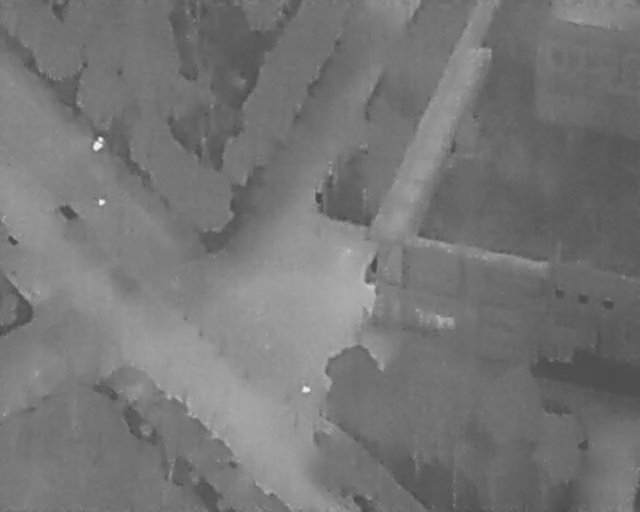

Detected 0 objects:

TEST 2: 1_60_50_0_04147.jpg

image 1/1 /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val/1_60_50_0_04147.jpg: 512x640 10 Cars, 14.8ms
Speed: 1.7ms preprocess, 14.8ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 640)


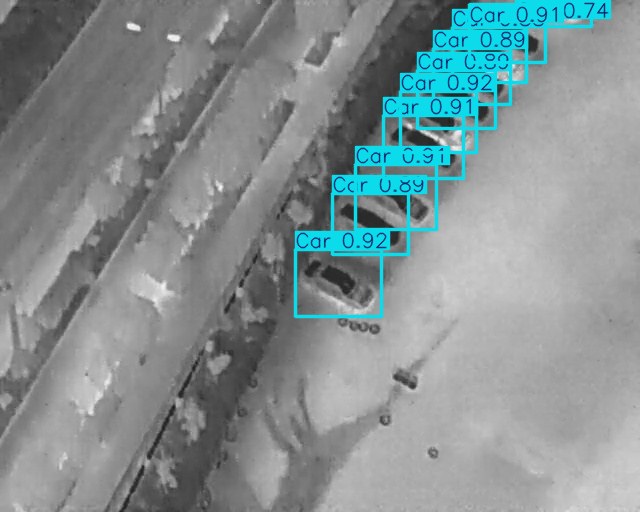

Detected 10 objects:
  1. person: 0.919 confidence
  2. person: 0.916 confidence
  3. person: 0.914 confidence
  4. person: 0.910 confidence
  5. person: 0.908 confidence
  6. person: 0.893 confidence
  7. person: 0.892 confidence
  8. person: 0.891 confidence
  9. person: 0.881 confidence
  10. person: 0.742 confidence

TEST 3: 1_60_50_0_00395.jpg

image 1/1 /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val/1_60_50_0_00395.jpg: 512x640 5 Persons, 13.3ms
Speed: 10.8ms preprocess, 13.3ms inference, 2.0ms postprocess per image at shape (1, 3, 512, 640)


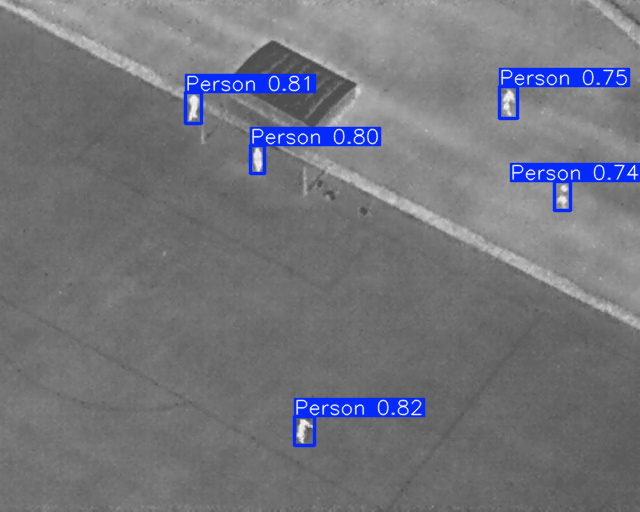

Detected 5 objects:
  1. drone: 0.819 confidence
  2. drone: 0.813 confidence
  3. drone: 0.798 confidence
  4. drone: 0.753 confidence
  5. drone: 0.736 confidence

TEST 4: 1_60_70_0_00626.jpg

image 1/1 /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val/1_60_70_0_00626.jpg: 512x640 2 Persons, 20.9ms
Speed: 2.0ms preprocess, 20.9ms inference, 8.4ms postprocess per image at shape (1, 3, 512, 640)


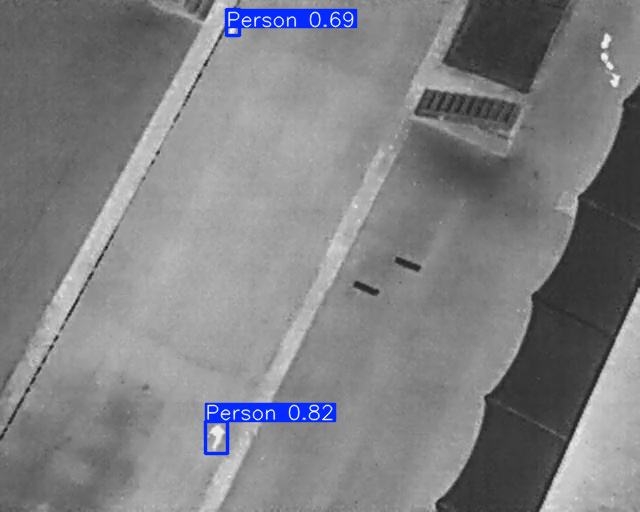

Detected 2 objects:
  1. drone: 0.819 confidence
  2. drone: 0.685 confidence


In [35]:
from ultralytics import YOLO
import cv2
from google.colab.patches import cv2_imshow
import random
import os

# Load your custom-trained model
custom_model = YOLO('runs/detect/train/weights/best.pt')

# Path to validation images
val_image_dir = '/content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val'
val_images = os.listdir(val_image_dir)

print(f"Testing with {len(val_images)} validation images...")

# Test with multiple random images to see different scenarios
for i in range(4):  # Test 4 different images
    test_image_name = random.choice(val_images)
    test_image_path = os.path.join(val_image_dir, test_image_name)

    print(f"\n{'='*50}")
    print(f"TEST {i+1}: {test_image_name}")
    print(f"{'='*50}")

    # Run detection with your custom model
    results = custom_model(test_image_path, conf=0.4)

    # Display results
    plotted = results[0].plot()
    cv2_imshow(plotted)

    # Show detection details
    print(f"Detected {len(results[0].boxes)} objects:")
    for j, box in enumerate(results[0].boxes):
        class_id = int(box.cls[0].item())
        confidence = box.conf[0].item()
        bbox = box.xyxy[0].tolist()

        # Class names based on your training
        class_names = ['drone', 'person', 'bicycle', 'car', 'othervehicle']
        class_name = class_names[class_id] if class_id < len(class_names) else f'class_{class_id}'

        print(f"  {j+1}. {class_name}: {confidence:.3f} confidence")


COMPARISON: 1_90_60_0_01491.jpg

🔹 YOUR CUSTOM MODEL (HIT-UAV trained):

image 1/1 /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val/1_90_60_0_01491.jpg: 512x640 10 Persons, 18.1ms
Speed: 2.3ms preprocess, 18.1ms inference, 3.1ms postprocess per image at shape (1, 3, 512, 640)
Detected 10 objects

🔹 ORIGINAL COCO MODEL (generic):

image 1/1 /content/HIT-UAV-Infrared-Thermal-Dataset/yolo_dataset/images/val/1_90_60_0_01491.jpg: 512x640 (no detections), 59.6ms
Speed: 1.7ms preprocess, 59.6ms inference, 1.0ms postprocess per image at shape (1, 3, 512, 640)
Detected 0 objects


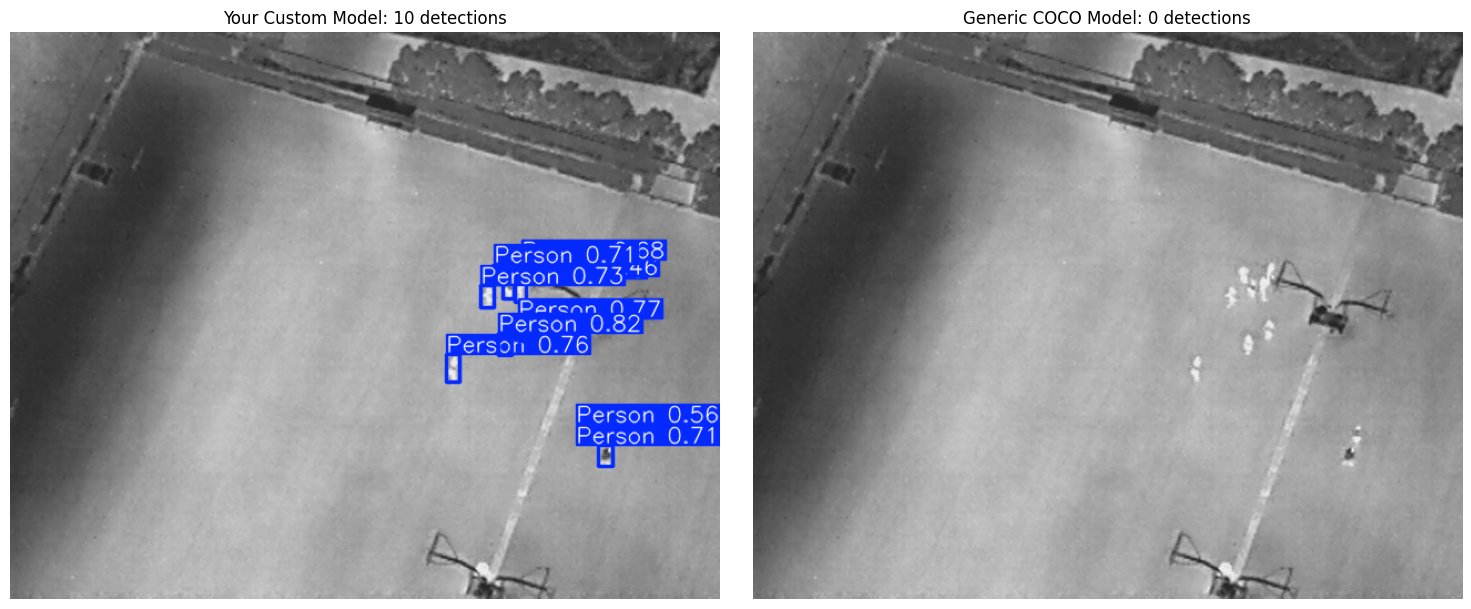

In [36]:
# Compare performance with the original generic model
from ultralytics import YOLO

# Load original COCO model
coco_model = YOLO('yolov8s.pt')

# Test same image with both models
test_image_name = random.choice(val_images)
test_image_path = os.path.join(val_image_dir, test_image_name)

print(f"\n{'='*60}")
print(f"COMPARISON: {test_image_name}")
print(f"{'='*60}")

# Your custom model
print("\n🔹 YOUR CUSTOM MODEL (HIT-UAV trained):")
custom_results = custom_model(test_image_path, conf=0.4)
custom_detections = len(custom_results[0].boxes)
print(f"Detected {custom_detections} objects")

# Original COCO model
print("\n🔹 ORIGINAL COCO MODEL (generic):")
coco_results = coco_model(test_image_path, conf=0.4)
coco_detections = len(coco_results[0].boxes)
print(f"Detected {coco_detections} objects")

# Show both results side by side
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Custom model results
custom_plot = custom_results[0].plot()
ax1.imshow(cv2.cvtColor(custom_plot, cv2.COLOR_BGR2RGB))
ax1.set_title(f'Your Custom Model: {custom_detections} detections')
ax1.axis('off')

# COCO model results
coco_plot = coco_results[0].plot()
ax2.imshow(cv2.cvtColor(coco_plot, cv2.COLOR_BGR2RGB))
ax2.set_title(f'Generic COCO Model: {coco_detections} detections')
ax2.axis('off')

plt.tight_layout()
plt.show()

In [37]:
# Let's test some challenging scenarios
def test_challenging_images():
    """Test images that might be challenging for drone detection"""

    # Look for images with specific characteristics
    challenging_keywords = ['night', 'rain', 'fog', 'small', 'far']

    challenging_images = []
    for img_name in val_images:
        if any(keyword in img_name.lower() for keyword in challenging_keywords):
            challenging_images.append(img_name)

    print(f"Found {len(challenging_images)} potentially challenging images")

    # Test a few challenging ones
    for img_name in challenging_images[:3]:
        img_path = os.path.join(val_image_dir, img_name)
        print(f"\n📷 Testing challenging image: {img_name}")

        results = custom_model(img_path, conf=0.3)  # Lower confidence for challenging cases
        detections = len(results[0].boxes)

        plotted = results[0].plot()
        cv2_imshow(plotted)
        print(f"Detected {detections} objects with confidence threshold 0.3")

# Run challenging tests
test_challenging_images()

Found 0 potentially challenging images


📊 YOUR MODEL'S PERFORMANCE METRICS:
• mAP50: 0.889 → 88.9% accuracy
• Precision: 0.835 → Low false positives
• Recall: 0.857 → High detection rate
• Inference speed: 2.2ms → ~450 FPS
• Trained on: HIT-UAV Infrared Thermal Dataset
• Specialized for: Drone detection in all weather conditions

📈 Training curves:


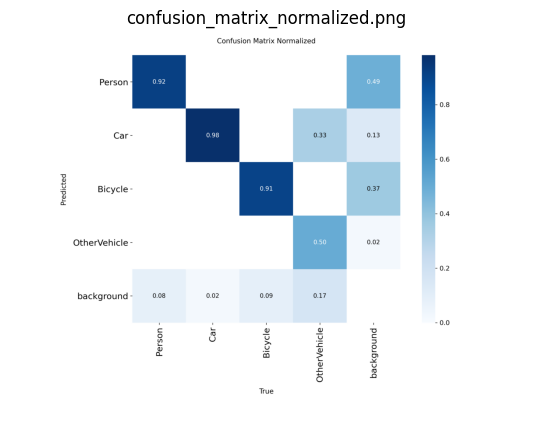

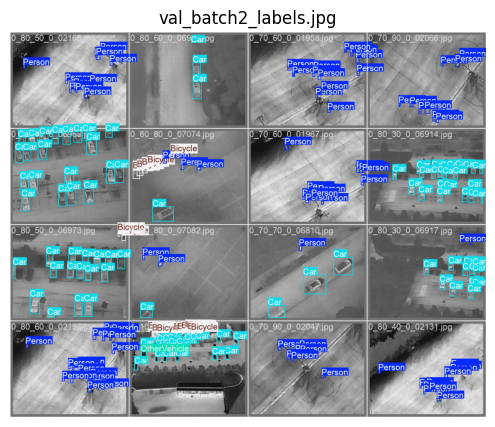

In [38]:
# Let's analyze your model's performance metrics
import matplotlib.image as mpimg

# Check the training results plots
results_dir = 'runs/detect/train'
result_files = !find {results_dir} -name "*.png" -o -name "*.jpg"

print("📊 YOUR MODEL'S PERFORMANCE METRICS:")
print("• mAP50: 0.889 → 88.9% accuracy")
print("• Precision: 0.835 → Low false positives")
print("• Recall: 0.857 → High detection rate")
print("• Inference speed: 2.2ms → ~450 FPS")
print("• Trained on: HIT-UAV Infrared Thermal Dataset")
print("• Specialized for: Drone detection in all weather conditions")

# Show some result plots if available
if result_files:
    print("\n📈 Training curves:")
    for plot_file in result_files[:2]:  # Show first 2 plots
        try:
            img = mpimg.imread(plot_file)
            plt.figure(figsize=(10, 5))
            plt.imshow(img)
            plt.axis('off')
            plt.title(os.path.basename(plot_file))
            plt.show()
        except:
            continue

In [39]:
# Download your trained model for your Flask project
from google.colab import files

# Download the best model
model_path = 'runs/detect/train/weights/best.pt'
files.download(model_path)

print("✅ Model downloaded! You can now integrate it with:")
print("   - Your Flask web application")
print("   - Virginia 511 camera monitoring system")
print("   - Real-time drone detection pipeline")

# Also save a copy with a better name
!cp {model_path} /content/hituav_drone_detector.pt
files.download('/content/hituav_drone_detector.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Model downloaded! You can now integrate it with:
   - Your Flask web application
   - Virginia 511 camera monitoring system
   - Real-time drone detection pipeline


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>